# Pairs Trading Across Sector ETFs: Mean Reversion from Weighting & Flow Frictions

**MGMTMFE-413 Statistical Arbitrage Research Project**

## Project Overview

This notebook implements a comprehensive pairs trading strategy on same-sector ETF pairs that:
- Uses time-varying hedge ratios via Kalman filtering
- Models spread mean reversion as an OU/AR(1) process
- Conditions signals on flow differentials and holdings overlap
- Implements robust backtesting with purged & embargoed walk-forward validation
- Includes robustness checks (SPA test, structural breaks, event studies)

## Table of Contents

1. [Setup and Configuration](#setup)
2. [Data Loading and Preprocessing](#data)
3. [Hedge Ratio Estimation (Kalman Filter)](#kalman)
4. [Mean Reversion Analysis](#meanrev)
5. [Signal Generation](#signals)
6. [Portfolio Construction and Optimization](#portfolio)



## 1. Setup and Configuration {#setup}


In [1]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import config
from data_loader import ETFDataLoader
from wrds_loader import WRDSETFLoader, load_etf_pairs_from_wrds
from kalman_filter import KalmanFilter, estimate_hedge_ratio_kalman
from mean_reversion import estimate_ar1, rolling_ar1, adf_test, compute_mean_reversion_metrics
from signal_generation import generate_signals, compute_position_sizes, compute_zscore
from backtesting import WalkForwardBacktest, run_backtest
from performance import compute_performance_metrics, compute_rolling_metrics
from robustness import (
    spa_test, detect_structural_breaks, event_study,
    identify_large_flow_events, compute_robustness_checks
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"ETF Pairs: {config.ETF_PAIRS}")


✓ Imports successful
Project root: /Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project
ETF Pairs: [('XLE', 'VDE', 'Energy'), ('XLK', 'FTEC', 'Technology'), ('XLF', 'VFH', 'Financials'), ('XLI', 'VIS', 'Industrials'), ('XLV', 'VHT', 'Healthcare')]


## 2. Data Loading and Preprocessing {#data}

**Note:** This section assumes you have data files or will connect to WRDS/Refinitiv.
For demonstration, we'll show the structure and provide placeholder code.


In [2]:
# Load all ETF pairs from WRDS
from wrds_loader import WRDSETFLoader

# Initialize WRDS loader
wrds_username = 'chalakorn'
loader = WRDSETFLoader(wrds_username=wrds_username, data_dir='data/raw')

print("="*70)
print("Loading All ETF Pairs from WRDS")
print("="*70)
print(f"Date range: {config.START_DATE} to {config.END_DATE}")
print(f"Total pairs to load: {len(config.ETF_PAIRS)}\n")

# Get all unique symbols first
all_symbols = set()
for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    all_symbols.add(symbol_a)
    all_symbols.add(symbol_b)

print(f"Step 1: Loading {len(all_symbols)} unique ETFs...")
print("-"*70)

# Load all unique ETFs first
loaded_symbols = {}
for symbol in sorted(all_symbols):
    print(f"  Loading {symbol}...", end=" ")
    try:
        data = loader.load_etf_price_data_wrds(
            symbol,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        if not data.empty:
            loaded_symbols[symbol] = data
            date_range = f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}"
            print(f"✓ {len(data)} days ({date_range})")
        else:
            print(f"✗ No data returned")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Successfully loaded {len(loaded_symbols)}/{len(all_symbols)} ETFs")

# Step 2: Create pair datasets
print(f"\nStep 2: Creating {len(config.ETF_PAIRS)} pair datasets...")
print("-"*70)

pair_datasets = {}
pair_summary = []

for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    print(f"\n  Pair: {symbol_a} - {symbol_b} ({sector})")
    
    # Check if both ETFs are loaded
    if symbol_a not in loaded_symbols:
        print(f"    ✗ {symbol_a} not loaded - skipping pair")
        continue
    if symbol_b not in loaded_symbols:
        print(f"    ✗ {symbol_b} not loaded - skipping pair")
        continue
    
    try:
        # Create pair dataset
        pair_data = loader.create_pair_dataset(
            symbol_a, symbol_b,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        
        if not pair_data.empty:
            pair_data['sector'] = sector
            pair_datasets[(symbol_a, symbol_b)] = pair_data
            
            # Summary info
            date_range = f"{pair_data.index.min().strftime('%Y-%m-%d')} to {pair_data.index.max().strftime('%Y-%m-%d')}"
            print(f"    ✓ Created pair dataset: {len(pair_data)} days ({date_range})")
            
            pair_summary.append({
                'Pair': f"{symbol_a}-{symbol_b}",
                'Sector': sector,
                'Days': len(pair_data),
                'Start': pair_data.index.min().strftime('%Y-%m-%d'),
                'End': pair_data.index.max().strftime('%Y-%m-%d')
            })
        else:
            print(f"    ✗ No overlapping data between {symbol_a} and {symbol_b}")
            
    except Exception as e:
        import traceback
        print(f"    ✗ Error creating pair: {str(e)[:100]}")
        print(f"    {traceback.format_exc()[:200]}")

# Close WRDS connection
loader.close()

# Final summary
print("\n" + "="*70)
print("LOADING SUMMARY")
print("="*70)
print(f"ETFs loaded: {len(loaded_symbols)}/{len(all_symbols)}")
print(f"Pairs created: {len(pair_datasets)}/{len(config.ETF_PAIRS)}")

if pair_summary:
    summary_df = pd.DataFrame(pair_summary)
    print("\nPair datasets:")
    display(summary_df)
    
    # Save summary
    summary_df.to_csv('pair_summary.csv', index=False)
    print("\n✓ Summary saved to results/pair_summary.csv")

# Store pair_datasets for use in subsequent cells
print(f"\n✓ Data loading complete!")
print(f"  Use 'pair_datasets' dictionary to access pair data")
print(f"  Example: pair_data = pair_datasets[('XLE', 'VDE')]")


Loading library list...
Done
✓ WRDS connection established
Loading All ETF Pairs from WRDS
Date range: 2010-01-01 to 2024-12-31
Total pairs to load: 5

Step 1: Loading 10 unique ETFs...
----------------------------------------------------------------------
  Loading FTEC...     Using permno 14205 for FTEC
    ✓ Loaded 2815 rows from dsf
✓ 2815 days (2013-10-24 to 2024-12-31)
  Loading VDE...     Using permno 90347 for VDE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VFH...     Using permno 89994 for VFH
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VHT...     Using permno 89995 for VHT
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VIS...     Using permno 90348 for VIS
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLE...     Using permno 86454 for XLE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLF...     Using 

,Pair,Sector,Days,Start,End
0,XLE-VDE,Energy,3774,2010-01-04,2024-12-31
1,XLK-FTEC,Technology,2815,2013-10-24,2024-12-31
2,XLF-VFH,Financials,3774,2010-01-04,2024-12-31
3,XLI-VIS,Industrials,3774,2010-01-04,2024-12-31
4,XLV-VHT,Healthcare,3774,2010-01-04,2024-12-31



✓ Summary saved to results/pair_summary.csv

✓ Data loading complete!
  Use 'pair_datasets' dictionary to access pair data
  Example: pair_data = pair_datasets[('XLE', 'VDE')]


## 2.5. Pair Selection and Ranking {#pair_selection}

**New Approach:** Instead of using a fixed set of 5 pairs, we:
1. Load 20-50 candidate ETF pairs
2. Compute correlation, cointegration, and stationarity metrics
3. Rank pairs by quality score
4. Select the best 10-15 pairs for trading

This ensures we trade only highly correlated, cointegrated pairs with good mean reversion properties.


In [3]:
# Import pair selection module
from pair_selection import (
    EXPANDED_ETF_PAIRS,
    compute_pair_correlation,
    test_cointegration,
    compute_spread_stationarity,
    rank_pairs,
    select_best_pairs
)

# Initialize WRDS loader for pair selection
# (The loader from Cell 4 may have been closed, so we create a new one)
print("="*70)
print("Pair Selection: Loading Expanded Candidate Pairs")
print("="*70)
print(f"Total candidate pairs: {len(EXPANDED_ETF_PAIRS)}")
print(f"Target selection: 10-15 best pairs\n")

# Create new WRDS loader
wrds_username = 'chalakorn'
pair_selection_loader = WRDSETFLoader(wrds_username=wrds_username, data_dir='data/raw')

# Extract all unique symbols from expanded pairs
all_candidate_symbols = set()
for symbol_a, symbol_b, sector, desc in EXPANDED_ETF_PAIRS:
    all_candidate_symbols.add(symbol_a)
    all_candidate_symbols.add(symbol_b)

print(f"Step 1: Loading {len(all_candidate_symbols)} unique ETFs from candidate pairs...")
print("-"*70)

# Load all candidate ETFs
candidate_loaded_symbols = {}
for symbol in sorted(all_candidate_symbols):
    print(f"  Loading {symbol}...", end=" ")
    try:
        data = pair_selection_loader.load_etf_price_data_wrds(
            symbol,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        if not data.empty:
            candidate_loaded_symbols[symbol] = data
            date_range = f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}"
            print(f"✓ {len(data)} days ({date_range})")
        else:
            print(f"✗ No data returned")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Successfully loaded {len(candidate_loaded_symbols)}/{len(all_candidate_symbols)} candidate ETFs")


Pair Selection: Loading Expanded Candidate Pairs
Total candidate pairs: 41
Target selection: 10-15 best pairs

Loading library list...
Done
✓ WRDS connection established
Step 1: Loading 41 unique ETFs from candidate pairs...
----------------------------------------------------------------------
  Loading FTEC...     Using permno 14205 for FTEC
    ✓ Loaded 2815 rows from dsf
✓ 2815 days (2013-10-24 to 2024-12-31)
  Loading IBB...     Using permno 88893 for IBB
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading IDU...     Using permno 88292 for IDU
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading IGV...     Using permno 89060 for IGV
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading IYC...     Using permno 88291 for IYC
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading IYE...     Using permno 88298 for IYE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 

In [4]:
# Step 2: Create pair datasets for all candidate pairs
print(f"\nStep 2: Creating {len(EXPANDED_ETF_PAIRS)} candidate pair datasets...")
print("-"*70)

candidate_pair_datasets = {}
candidate_pair_summary = []

for symbol_a, symbol_b, sector, desc in EXPANDED_ETF_PAIRS:
    print(f"\n  Pair: {symbol_a} - {symbol_b} ({sector})")
    
    # Check if both ETFs are loaded
    if symbol_a not in candidate_loaded_symbols:
        print(f"    ✗ {symbol_a} not loaded - skipping pair")
        continue
    if symbol_b not in candidate_loaded_symbols:
        print(f"    ✗ {symbol_b} not loaded - skipping pair")
        continue
    
    try:
        # Create pair dataset
        pair_data = pair_selection_loader.create_pair_dataset(
            symbol_a, symbol_b,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        
        if not pair_data.empty and len(pair_data) >= 252:  # Require at least 1 year of data
            pair_data['sector'] = sector
            candidate_pair_datasets[(symbol_a, symbol_b)] = pair_data
            
            # Summary info
            date_range = f"{pair_data.index.min().strftime('%Y-%m-%d')} to {pair_data.index.max().strftime('%Y-%m-%d')}"
            print(f"    ✓ Created pair dataset: {len(pair_data)} days ({date_range})")
            
            candidate_pair_summary.append({
                'Pair': f"{symbol_a}-{symbol_b}",
                'Sector': sector,
                'Description': desc,
                'Days': len(pair_data),
                'Start': pair_data.index.min().strftime('%Y-%m-%d'),
                'End': pair_data.index.max().strftime('%Y-%m-%d')
            })
        else:
            print(f"    ✗ Insufficient data ({len(pair_data) if not pair_data.empty else 0} days)")
            
    except Exception as e:
        print(f"    ✗ Error creating pair: {str(e)[:100]}")

print(f"\n✓ Created {len(candidate_pair_datasets)}/{len(EXPANDED_ETF_PAIRS)} candidate pair datasets")

if candidate_pair_summary:
    summary_df = pd.DataFrame(candidate_pair_summary)
    print("\nCandidate Pair Summary:")
    display(summary_df.head(20))  # Show first 20
    if len(summary_df) > 20:
        print(f"... and {len(summary_df) - 20} more pairs")



Step 2: Creating 41 candidate pair datasets...
----------------------------------------------------------------------

  Pair: XLE - VDE (Energy)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: XLE - IYE (Energy)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: VDE - IYE (Energy)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: XLK - FTEC (Technology)
    ✓ Created pair dataset: 2815 days (2013-10-24 to 2024-12-31)

  Pair: XLK - VGT (Technology)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: FTEC - VGT (Technology)
    ✓ Created pair dataset: 2815 days (2013-10-24 to 2024-12-31)

  Pair: XLK - IGV (Technology)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: XLF - VFH (Financials)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: XLF - IYF (Financials)
    ✓ Created pair dataset: 3774 days (2010-01-04 to 2024-12-31)

  Pair: VFH - IYF

,Pair,Sector,Description,Days,Start,End
0,XLE-VDE,Energy,SPDR vs Vanguard Energy,3774,2010-01-04,2024-12-31
1,XLE-IYE,Energy,SPDR vs iShares Energy,3774,2010-01-04,2024-12-31
2,VDE-IYE,Energy,Vanguard vs iShares Energy,3774,2010-01-04,2024-12-31
3,XLK-FTEC,Technology,SPDR vs Fidelity Technology,2815,2013-10-24,2024-12-31
4,XLK-VGT,Technology,SPDR vs Vanguard Technology,3774,2010-01-04,2024-12-31
5,FTEC-VGT,Technology,Fidelity vs Vanguard Technology,2815,2013-10-24,2024-12-31
6,XLK-IGV,Technology,SPDR vs iShares Software,3774,2010-01-04,2024-12-31
7,XLF-VFH,Financials,SPDR vs Vanguard Financials,3774,2010-01-04,2024-12-31
8,XLF-IYF,Financials,SPDR vs iShares Financials,3774,2010-01-04,2024-12-31
9,VFH-IYF,Financials,Vanguard vs iShares Financials,3774,2010-01-04,2024-12-31


... and 21 more pairs


In [5]:
# Step 3: Compute spreads using Kalman filter for all candidate pairs
print("\n" + "="*70)
print("Step 3: Computing Spreads for All Candidate Pairs")
print("="*70)
print("This may take a few minutes...\n")

candidate_spreads = {}
candidate_kalman_results = {}

for i, ((symbol_a, symbol_b), pair_data) in enumerate(candidate_pair_datasets.items(), 1):
    pair_name = f"{symbol_a}-{symbol_b}"
    print(f"[{i}/{len(candidate_pair_datasets)}] Processing {pair_name}...", end=" ")
    
    try:
        # Run Kalman filter to get spread
        kalman_result = estimate_hedge_ratio_kalman(pair_data, config=config.KALMAN_CONFIG)
        spread = kalman_result['spread']
        
        candidate_spreads[(symbol_a, symbol_b)] = spread
        candidate_kalman_results[(symbol_a, symbol_b)] = kalman_result
        
        print(f"✓ Spread computed ({len(spread)} days)")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Computed spreads for {len(candidate_spreads)}/{len(candidate_pair_datasets)} pairs")



Step 3: Computing Spreads for All Candidate Pairs
This may take a few minutes...

[1/41] Processing XLE-VDE... ✓ Spread computed (3774 days)
[2/41] Processing XLE-IYE... ✓ Spread computed (3774 days)
[3/41] Processing VDE-IYE... ✓ Spread computed (3774 days)
[4/41] Processing XLK-FTEC... ✓ Spread computed (2815 days)
[5/41] Processing XLK-VGT... ✓ Spread computed (3774 days)
[6/41] Processing FTEC-VGT... ✓ Spread computed (2815 days)
[7/41] Processing XLK-IGV... ✓ Spread computed (3774 days)
[8/41] Processing XLF-VFH... ✓ Spread computed (3774 days)
[9/41] Processing XLF-IYF... ✓ Spread computed (3774 days)
[10/41] Processing VFH-IYF... ✓ Spread computed (3774 days)
[11/41] Processing XLF-KBE... ✓ Spread computed (3774 days)
[12/41] Processing XLI-VIS... ✓ Spread computed (3774 days)
[13/41] Processing XLI-IYJ... ✓ Spread computed (3774 days)
[14/41] Processing VIS-IYJ... ✓ Spread computed (3774 days)
[15/41] Processing XLV-VHT... ✓ Spread computed (3774 days)
[16/41] Processing XLV-I

In [6]:
# Step 4: Rank all candidate pairs by quality metrics
print("\n" + "="*70)
print("Step 4: Ranking Candidate Pairs by Quality Metrics")
print("="*70)
print("Computing correlation, cointegration, and stationarity metrics...\n")

ranked_pairs_df = rank_pairs(
    candidate_pair_datasets,
    spreads=candidate_spreads
)

print(f"✓ Ranked {len(ranked_pairs_df)} pairs")
print("\nTop 20 Pairs by Quality Score:")
print("-"*70)
display(ranked_pairs_df.head(20).style.format({
    'quality_score': '{:.2f}',
    'mean_correlation': '{:.4f}',
    'correlation_stability': '{:.4f}',
    'cointegration_pvalue': '{:.4f}',
    'adf_pvalue': '{:.4f}'
}))

# Save ranking to CSV
ranked_pairs_df.to_csv('results/ranked_pairs.csv', index=False)
print("\n✓ Saved ranking to results/ranked_pairs.csv")



Step 4: Ranking Candidate Pairs by Quality Metrics
Computing correlation, cointegration, and stationarity metrics...

✓ Ranked 41 pairs

Top 20 Pairs by Quality Score:
----------------------------------------------------------------------


,pair,symbol_a,symbol_b,n_days,quality_score,mean_correlation,correlation_stability,cointegrated,cointegration_pvalue,spread_stationary,adf_pvalue,stationarity_score,data_quality_score,correlation_score,cointegration_score,rank
0,XLRE-IYR,XLRE,IYR,2323,98.72,0.9830,0.9825,True,0.0000,False,1.0000,nan,20,28.972396,30.000000,1
1,XLRE-VNQ,XLRE,VNQ,2323,98.41,0.9773,0.9799,True,0.0000,False,1.0000,nan,20,28.729803,30.000000,2
2,XLB-VAW,XLB,VAW,3774,69.53,0.9895,0.9948,False,0.0581,True,0.0000,20.000000,20,29.531255,nan,3
3,XLC-VOX,XLC,VOX,1645,69.42,0.9868,0.9937,False,0.9348,True,0.0000,20.000000,20,29.418030,nan,4
4,XLV-VHT,XLV,VHT,3774,69.31,0.9861,0.9907,False,0.5843,True,0.0000,20.000000,20,29.307816,nan,5
5,VAW-IYM,VAW,IYM,3774,69.30,0.9846,0.9918,False,0.3188,True,0.0000,20.000000,20,29.295744,nan,6
6,VFH-IYF,VFH,IYF,3774,69.27,0.9868,0.9887,False,0.9798,True,0.0000,20.000000,20,29.270119,nan,7
7,VIS-IYJ,VIS,IYJ,3774,69.26,0.9858,0.9894,False,0.9680,True,0.0000,20.000000,20,29.262110,nan,8
8,XLF-IYF,XLF,IYF,3774,69.15,0.9832,0.9882,False,0.9100,True,0.0000,20.000000,20,29.147372,nan,9
9,XLB-IYM,XLB,IYM,3774,69.11,0.9801,0.9901,False,0.2289,True,0.0000,20.000000,20,29.113363,nan,10



✓ Saved ranking to results/ranked_pairs.csv


In [7]:
# Step 5: Select best pairs based on quality metrics
print("\n" + "="*70)
print("Step 5: Selecting Best Pairs for Trading")
print("="*70)

# Selection criteria
N_SELECTED_PAIRS = 15  # Target number of pairs
MIN_QUALITY_SCORE = 50.0  # Minimum quality score (0-100)
MIN_CORRELATION = 0.70  # Minimum correlation
REQUIRE_COINTEGRATION = False  # Set to True to require cointegration

selected_pairs = select_best_pairs(
    ranked_pairs_df,
    n_pairs=N_SELECTED_PAIRS,
    min_quality_score=MIN_QUALITY_SCORE,
    min_correlation=MIN_CORRELATION,
    require_cointegration=REQUIRE_COINTEGRATION
)

print(f"\nSelected {len(selected_pairs)} pairs for trading:")
print("-"*70)
for i, (symbol_a, symbol_b) in enumerate(selected_pairs, 1):
    pair_name = f"{symbol_a}-{symbol_b}"
    pair_info = ranked_pairs_df[ranked_pairs_df['pair'] == pair_name].iloc[0]
    print(f"{i:2d}. {pair_name:15s} | Quality: {pair_info['quality_score']:5.2f} | "
          f"Corr: {pair_info['mean_correlation']:6.3f} | "
          f"Coint: {'Yes' if pair_info['cointegrated'] else 'No'} | "
          f"Stationary: {'Yes' if pair_info['spread_stationary'] else 'No'}")

# Create selected pair datasets dictionary
selected_pair_datasets = {
    (symbol_a, symbol_b): candidate_pair_datasets[(symbol_a, symbol_b)]
    for symbol_a, symbol_b in selected_pairs
    if (symbol_a, symbol_b) in candidate_pair_datasets
}

print(f"\n✓ Selected {len(selected_pair_datasets)} pairs for further analysis")
print(f"\nNote: These selected pairs will be used for the rest of the analysis.")
print(f"Update 'pair_datasets' variable to use selected pairs instead of original 5 pairs.")



Step 5: Selecting Best Pairs for Trading

Selected 15 pairs for trading:
----------------------------------------------------------------------
 1. XLRE-IYR        | Quality: 98.72 | Corr:  0.983 | Coint: Yes | Stationary: No
 2. XLRE-VNQ        | Quality: 98.41 | Corr:  0.977 | Coint: Yes | Stationary: No
 3. XLB-VAW         | Quality: 69.53 | Corr:  0.989 | Coint: No | Stationary: Yes
 4. XLC-VOX         | Quality: 69.42 | Corr:  0.987 | Coint: No | Stationary: Yes
 5. XLV-VHT         | Quality: 69.31 | Corr:  0.986 | Coint: No | Stationary: Yes
 6. VAW-IYM         | Quality: 69.30 | Corr:  0.985 | Coint: No | Stationary: Yes
 7. VFH-IYF         | Quality: 69.27 | Corr:  0.987 | Coint: No | Stationary: Yes
 8. VIS-IYJ         | Quality: 69.26 | Corr:  0.986 | Coint: No | Stationary: Yes
 9. XLF-IYF         | Quality: 69.15 | Corr:  0.983 | Coint: No | Stationary: Yes
10. XLB-IYM         | Quality: 69.11 | Corr:  0.980 | Coint: No | Stationary: Yes
11. XLI-IYJ         | Quality: 69.0

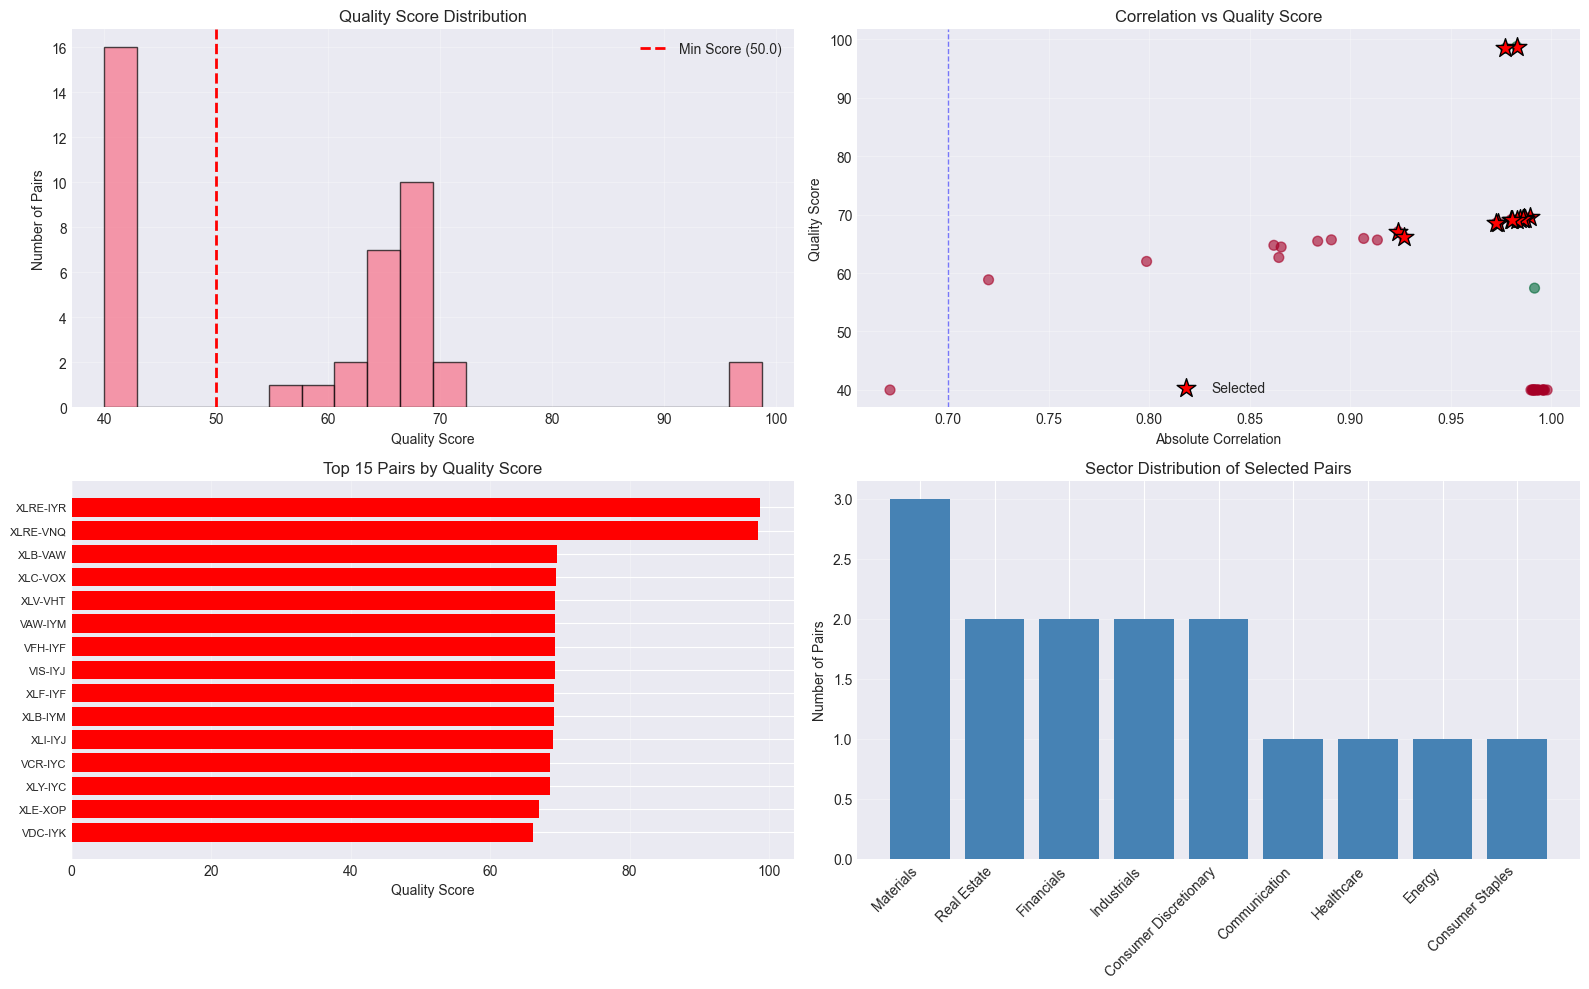


✓ Pair selection visualization complete!


In [8]:
# Visualize pair selection results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Quality Score Distribution
axes[0, 0].hist(ranked_pairs_df['quality_score'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(MIN_QUALITY_SCORE, color='red', linestyle='--', linewidth=2, label=f'Min Score ({MIN_QUALITY_SCORE})')
axes[0, 0].set_xlabel('Quality Score')
axes[0, 0].set_ylabel('Number of Pairs')
axes[0, 0].set_title('Quality Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Correlation vs Quality Score
scatter = axes[0, 1].scatter(ranked_pairs_df['mean_correlation'].abs(), 
                             ranked_pairs_df['quality_score'],
                             c=ranked_pairs_df['cointegrated'].astype(int),
                             cmap='RdYlGn', alpha=0.6, s=50)
selected_mask = ranked_pairs_df['pair'].isin([f"{a}-{b}" for a, b in selected_pairs])
axes[0, 1].scatter(ranked_pairs_df.loc[selected_mask, 'mean_correlation'].abs(),
                   ranked_pairs_df.loc[selected_mask, 'quality_score'],
                   color='red', marker='*', s=200, label='Selected', edgecolors='black', linewidths=1)
axes[0, 1].axvline(MIN_CORRELATION, color='blue', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_xlabel('Absolute Correlation')
axes[0, 1].set_ylabel('Quality Score')
axes[0, 1].set_title('Correlation vs Quality Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Top 15 Pairs by Quality Score
top_15 = ranked_pairs_df.head(15)
axes[1, 0].barh(range(len(top_15)), top_15['quality_score'], 
                color=['red' if pair in [f"{a}-{b}" for a, b in selected_pairs] else 'steelblue' 
                       for pair in top_15['pair']])
axes[1, 0].set_yticks(range(len(top_15)))
axes[1, 0].set_yticklabels(top_15['pair'], fontsize=8)
axes[1, 0].set_xlabel('Quality Score')
axes[1, 0].set_title('Top 15 Pairs by Quality Score')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Sector Distribution of Selected Pairs
if len(selected_pairs) > 0:
    selected_info = []
    for symbol_a, symbol_b in selected_pairs:
        pair_name = f"{symbol_a}-{symbol_b}"
        info = ranked_pairs_df[ranked_pairs_df['pair'] == pair_name]
        if not info.empty:
            # Try to get sector from original data
            sector = 'Unknown'
            for sym_a, sym_b, sec, _ in EXPANDED_ETF_PAIRS:
                if (sym_a == symbol_a and sym_b == symbol_b) or (sym_a == symbol_b and sym_b == symbol_a):
                    sector = sec
                    break
            selected_info.append({'pair': pair_name, 'sector': sector})
    
    if selected_info:
        sector_df = pd.DataFrame(selected_info)
        sector_counts = sector_df['sector'].value_counts()
        axes[1, 1].bar(range(len(sector_counts)), sector_counts.values, color='steelblue')
        axes[1, 1].set_xticks(range(len(sector_counts)))
        axes[1, 1].set_xticklabels(sector_counts.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Number of Pairs')
        axes[1, 1].set_title('Sector Distribution of Selected Pairs')
        axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Pair selection visualization complete!")


In [9]:
# Update pair_datasets to use selected pairs
# This replaces the original 5 pairs with the selected best pairs
print("="*70)
print("Updating pair_datasets to use selected pairs")
print("="*70)

# Option 1: Use selected pairs (recommended)
USE_SELECTED_PAIRS = True  # Set to False to use original 5 pairs

if USE_SELECTED_PAIRS and len(selected_pair_datasets) > 0:
    pair_datasets = selected_pair_datasets.copy()
    print(f"✓ Using {len(pair_datasets)} selected pairs (from correlation analysis)")
    print(f"  Selected pairs: {[f'{a}-{b}' for a, b in selected_pairs]}")
else:
    print("✓ Using original 5 pairs (from config.ETF_PAIRS)")
    # pair_datasets already contains original pairs from Cell 4

print(f"\nFinal pair_datasets contains {len(pair_datasets)} pairs")
print("These pairs will be used for the rest of the analysis (Kalman filter, signals, optimization, etc.)")

# Close the pair selection loader
pair_selection_loader.close()
print("\n✓ Closed WRDS connection for pair selection")


Updating pair_datasets to use selected pairs
✓ Using 15 selected pairs (from correlation analysis)
  Selected pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']

Final pair_datasets contains 15 pairs
These pairs will be used for the rest of the analysis (Kalman filter, signals, optimization, etc.)

✓ Closed WRDS connection for pair selection


In [10]:
# Convert pair_datasets to pair_data_dict format for compatibility with processing cells
# This ensures the selected pairs flow through to all subsequent analysis

print("="*70)
print("Preparing Selected Pairs for Processing")
print("="*70)

# Convert from pair_datasets format (tuple keys) to pair_data_dict format (string keys)
pair_data_dict = {}
for (symbol_a, symbol_b), pair_data in pair_datasets.items():
    pair_name = f"{symbol_a}-{symbol_b}"
    pair_data_dict[pair_name] = pair_data
    print(f"  ✓ Added {pair_name}: {len(pair_data)} days")

print(f"\n✓ Prepared {len(pair_data_dict)} selected pairs for processing")
print(f"\nThese pairs will be used for:")
print("  - Kalman filter estimation")
print("  - Signal generation")
print("  - Strategy returns computation")
print("  - Portfolio optimization")
print("  - All subsequent analysis")
print(f"\nSelected pairs: {list(pair_data_dict.keys())}")

# IMPORTANT: Save to a backup variable to prevent override
selected_pairs_backup = pair_data_dict.copy()
print(f"\n✓ Saved {len(selected_pairs_backup)} selected pairs to backup variable")


Preparing Selected Pairs for Processing
  ✓ Added XLRE-IYR: 2323 days
  ✓ Added XLRE-VNQ: 2323 days
  ✓ Added XLB-VAW: 3774 days
  ✓ Added XLC-VOX: 1645 days
  ✓ Added XLV-VHT: 3774 days
  ✓ Added VAW-IYM: 3774 days
  ✓ Added VFH-IYF: 3774 days
  ✓ Added VIS-IYJ: 3774 days
  ✓ Added XLF-IYF: 3774 days
  ✓ Added XLB-IYM: 3774 days
  ✓ Added XLI-IYJ: 3774 days
  ✓ Added VCR-IYC: 3774 days
  ✓ Added XLY-IYC: 3774 days
  ✓ Added XLE-XOP: 3774 days
  ✓ Added VDC-IYK: 3774 days

✓ Prepared 15 selected pairs for processing

These pairs will be used for:
  - Kalman filter estimation
  - Signal generation
  - Strategy returns computation
  - Portfolio optimization
  - All subsequent analysis

Selected pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']

✓ Saved 15 selected pairs to backup variable


In [11]:
# Save each pair_data DataFrame to a separate CSV file
import os

output_dir = "pair_data_csv"
os.makedirs(output_dir, exist_ok=True)

for (symbol_a, symbol_b), pair_data in pair_datasets.items():
    filename = f"{symbol_a}-{symbol_b}.csv"
    filepath = os.path.join(output_dir, filename)
    pair_data.to_csv(filepath)
    print(f"Saved {filename} to {output_dir}/")


Saved XLRE-IYR.csv to pair_data_csv/
Saved XLRE-VNQ.csv to pair_data_csv/
Saved XLB-VAW.csv to pair_data_csv/
Saved XLC-VOX.csv to pair_data_csv/
Saved XLV-VHT.csv to pair_data_csv/
Saved VAW-IYM.csv to pair_data_csv/
Saved VFH-IYF.csv to pair_data_csv/
Saved VIS-IYJ.csv to pair_data_csv/
Saved XLF-IYF.csv to pair_data_csv/
Saved XLB-IYM.csv to pair_data_csv/
Saved XLI-IYJ.csv to pair_data_csv/
Saved VCR-IYC.csv to pair_data_csv/
Saved XLY-IYC.csv to pair_data_csv/
Saved XLE-XOP.csv to pair_data_csv/
Saved VDC-IYK.csv to pair_data_csv/


## 3. Hedge Ratio Estimation (Kalman Filter) {#kalman}

Estimate time-varying hedge ratio using Kalman filter.


In [12]:
# Example workflow for Kalman filter estimation
# Assuming pair_data is loaded

def estimate_pair_hedge_ratio(symbol_a, symbol_b, pair_data):
    """
    Estimate hedge ratio for an ETF pair.
    
    This is a template - replace with actual data loading.
    """
    
    # Run Kalman filter
    kalman_result = estimate_hedge_ratio_kalman(
        pair_data,
        config=config.KALMAN_CONFIG
    )
    
    return kalman_result

# Example usage (uncomment when data is loaded):
pair_data = loader.create_pair_dataset('XLE', 'VDE', 
                                      start_date=config.START_DATE,
                                      end_date=config.END_DATE)
kalman_results = estimate_pair_hedge_ratio('XLE', 'VDE', pair_data)

print("Kalman filter estimation function ready.")
print("\nKey outputs:")
print("- beta_smoothed: Time-varying hedge ratio")
print("- spread: Spread series s_t = log_price_A - beta_t * log_price_B")


Kalman filter estimation function ready.

Key outputs:
- beta_smoothed: Time-varying hedge ratio
- spread: Spread series s_t = log_price_A - beta_t * log_price_B


In [13]:
kalman_results

,beta_filtered,beta_variance_filtered,beta_smoothed,beta_variance_smoothed,spread
date,,,,,
2010-01-04,0.915177,0.000050,0.915177,0.000050,-0.001886
2010-01-05,0.914660,0.000038,0.914660,0.000038,-0.000771
2010-01-06,0.914769,0.000037,0.914769,0.000037,0.000176
2010-01-07,0.914910,0.000037,0.914910,0.000037,0.000231
2010-01-08,0.914887,0.000036,0.914887,0.000036,-0.000038
...,...,...,...,...,...
2024-12-24,0.928136,0.000033,0.928136,0.000033,-0.000152
2024-12-26,0.928129,0.000033,0.928129,0.000033,-0.000011
2024-12-27,0.928084,0.000033,0.928084,0.000033,-0.000071


In [14]:
# CRITICAL: Ensure selected pairs are used (restore if overridden by CSV loading)
print("="*70)
print("Final Pair Selection Check")
print("="*70)

# Check if selected pairs backup exists (from Cell 13)
if 'selected_pairs_backup' in locals() and len(selected_pairs_backup) > 0:
    # Restore selected pairs
    pair_data_dict = selected_pairs_backup.copy()
    print(f"✓ Restored {len(pair_data_dict)} selected pairs from backup")
    print(f"  Using pairs: {list(pair_data_dict.keys())}")
    print(f"\n⚠️  If you see only 5 pairs, the CSV loading cell may have overridden them.")
    print(f"   This cell ensures the selected pairs are used instead.")
elif 'pair_data_dict' in locals() and len(pair_data_dict) > 0:
    print(f"✓ Using existing pair_data_dict with {len(pair_data_dict)} pairs")
    print(f"  Pairs: {list(pair_data_dict.keys())}")
else:
    print("⚠️  WARNING: No pairs found! Make sure to run pair selection cells (6-13) first.")
    print("   Falling back to loading from CSV files...")
    import os
    pair_data_dir = "pair_data_csv"
    pair_files = {
        'XLE-VDE': 'XLE-VDE.csv',
        'XLK-FTEC': 'XLK-FTEC.csv',
        'XLF-VFH': 'XLF-VFH.csv',
        'XLI-VIS': 'XLI-VIS.csv',
        'XLV-VHT': 'XLV-VHT.csv'
    }
    pair_data_dict = {}
    for pair_name, filename in pair_files.items():
        filepath = os.path.join(pair_data_dir, filename)
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, index_col='date', parse_dates=True)
            pair_data_dict[pair_name] = df

print(f"\n✓ Final: {len(pair_data_dict)} pairs ready for processing")
print(f"  Pairs: {list(pair_data_dict.keys())}")


Final Pair Selection Check
✓ Restored 15 selected pairs from backup
  Using pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']

⚠️  If you see only 5 pairs, the CSV loading cell may have overridden them.
   This cell ensures the selected pairs are used instead.

✓ Final: 15 pairs ready for processing
  Pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']


## 4. Mean Reversion Analysis {#meanrev}

Model spread as AR(1) process and compute half-life.


In [15]:
# Example mean reversion analysis
# Assuming spread is computed from Kalman filter

def analyze_mean_reversion(spread):
    """
    Analyze mean reversion properties of spread.
    """
    # Compute comprehensive metrics
    metrics = compute_mean_reversion_metrics(
        spread,
        config=config.MEAN_REVERSION_CONFIG
    )
    
    # Rolling AR(1) estimation
    rolling_ar1_results = rolling_ar1(
        spread,
        window=config.MEAN_REVERSION_CONFIG['ar1_window']
    )
    
    return metrics, rolling_ar1_results

# Example usage:
metrics, rolling = analyze_mean_reversion(kalman_results['spread'])

print("Mean reversion analysis functions ready.")
print("\nKey metrics:")
print("- mu: Mean reversion level")
print("- phi: AR(1) coefficient")
print("- half_life: Half-life in days")
print("- is_stationary: ADF test result")


Mean reversion analysis functions ready.

Key metrics:
- mu: Mean reversion level
- phi: AR(1) coefficient
- half_life: Half-life in days
- is_stationary: ADF test result


## 5. Signal Generation {#signals}

Generate trading signals with z-scores and flow/weighting conditions.


In [16]:
# Signal generation example

def generate_pair_signals(pair_data, spread, signal_config=None):
    """
    Generate trading signals for a pair.
    """
    if signal_config is None:
        signal_config = config.SIGNAL_CONFIG
    
    # Generate signals
    signals = generate_signals(pair_data, spread, signal_config)
    
    # Compute position sizes
    signals = compute_position_sizes(
        signals,
        pair_data,
        config.BACKTEST_CONFIG
    )
    
    return signals

# Example usage:
signals = generate_pair_signals(pair_data, kalman_results['spread'])

print("Signal generation functions ready.")
print("\nSignal logic:")
print("- Enter long when z-score < -z_entry AND flow condition met")
print("- Enter short when z-score > +z_entry AND flow condition met")
print("- Exit when |z-score| < z_exit OR max holding period OR stop loss")


Signal generation functions ready.

Signal logic:
- Enter long when z-score < -z_entry AND flow condition met
- Enter short when z-score > +z_entry AND flow condition met
- Exit when |z-score| < z_exit OR max holding period OR stop loss


In [17]:
signals

,spread,zscore,flow_diff,flow_diff_pct,flow_diff_pctile,signal,position,entry_date,entry_zscore,entry_spread,days_held,position_size_A,position_size_B,notional
date,,,,,,,,,,,,,,
2010-01-04,-0.001886,<NA>,0.0,0.0,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-05,-0.000771,<NA>,0.0,-0.002074,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-06,0.000176,<NA>,0.0,0.000461,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-07,0.000231,<NA>,0.0,0.00089,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2010-01-08,-0.000038,<NA>,0.0,-0.001021,NaN,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,-0.000152,-0.189924,0.0,0.000778,0.501984,-1,0,NaT,NaN,NaN,1,0.0,0.0,0.0
2024-12-26,-0.000011,0.149007,0.0,0.000178,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0
2024-12-27,-0.000071,0.026013,0.0,-0.000286,0.501984,0,0,NaT,NaN,NaN,0,0.0,0.0,0.0


## 6. Portfolio Construction and Optimization {#portfolio}

Load all pair CSV files, process each pair (Kalman filter, signals, returns), and optimize portfolio weights and hedge ratios.


In [18]:
# Import portfolio optimization module
from portfolio_optimization import (
    optimize_portfolio_weights,
    optimize_hedge_ratios,
    compute_portfolio_returns
)

# Define helper function for computing strategy returns
def compute_strategy_returns(signals, pair_data):
    """
    Compute strategy returns from signals and pair data (without transaction costs).
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: position_size_A, position_size_B
        (dollar positions in ETF A and ETF B)
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
        (returns for ETF A and ETF B)
    
    Returns:
    --------
    pd.Series : Strategy returns (same index as common dates)
    """
    # Align data on common dates
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get position sizes and returns
    pos_a = signals.loc[common_idx, 'position_size_A']
    pos_b = signals.loc[common_idx, 'position_size_B']
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Compute dollar P&L: positions * returns
    dollar_pnl = pos_a * returns_a + pos_b * returns_b
    
    # Compute notional (total exposure) for normalization
    notional = pos_a.abs() + pos_b.abs()
    
    # Normalize by notional to get returns
    # Use previous period's notional to avoid look-ahead bias
    prev_notional = notional.shift(1).fillna(notional)
    
    # Avoid division by zero
    strategy_returns = dollar_pnl / prev_notional.replace(0, np.nan)
    strategy_returns = strategy_returns.fillna(0.0)
    
    return strategy_returns

print("✓ Portfolio optimization module imported")
print("✓ Helper functions defined")


✓ Portfolio optimization module imported
✓ Helper functions defined


In [19]:
# Use selected pairs from pair selection (Cell 13) if available
# Otherwise, fall back to loading from CSV files (original 5 pairs)

print("="*70)
print("Loading Pairs for Processing")
print("="*70)

# Check if pair_data_dict was already created from selected pairs (Cell 13)
if 'pair_data_dict' in locals() and len(pair_data_dict) > 0:
    print(f"✓ Using {len(pair_data_dict)} selected pairs from pair selection analysis")
    print(f"  Selected pairs: {list(pair_data_dict.keys())}")
    print(f"\nThese pairs will be used for all subsequent processing:")
    print(f"  - Kalman filter estimation")
    print(f"  - Signal generation")
    print(f"  - Strategy returns computation")
    print(f"  - Portfolio optimization")
else:
    # Fallback: Load from CSV files (original 5 pairs)
    print("No selected pairs found. Loading original 5 pairs from CSV files...")
    import os
    
    pair_data_dir = "pair_data_csv"
    pair_files = {
        'XLE-VDE': 'XLE-VDE.csv',
        'XLK-FTEC': 'XLK-FTEC.csv',
        'XLF-VFH': 'XLF-VFH.csv',
        'XLI-VIS': 'XLI-VIS.csv',
        'XLV-VHT': 'XLV-VHT.csv'
    }
    
    # Load all pair data
    pair_data_dict = {}
    for pair_name, filename in pair_files.items():
        filepath = os.path.join(pair_data_dir, filename)
        if os.path.exists(filepath):
            df = pd.read_csv(filepath, index_col='date', parse_dates=True)
            pair_data_dict[pair_name] = df
            print(f"✓ Loaded {pair_name}: {len(df)} days ({df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')})")
        else:
            print(f"✗ File not found: {filepath}")
    
    print(f"\n✓ Loaded {len(pair_data_dict)}/{len(pair_files)} pairs from CSV files")

print(f"\n✓ Final pair_data_dict contains {len(pair_data_dict)} pairs")
print(f"  Pairs: {list(pair_data_dict.keys())}")


Loading Pairs for Processing
✓ Using 15 selected pairs from pair selection analysis
  Selected pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']

These pairs will be used for all subsequent processing:
  - Kalman filter estimation
  - Signal generation
  - Strategy returns computation
  - Portfolio optimization

✓ Final pair_data_dict contains 15 pairs
  Pairs: ['XLRE-IYR', 'XLRE-VNQ', 'XLB-VAW', 'XLC-VOX', 'XLV-VHT', 'VAW-IYM', 'VFH-IYF', 'VIS-IYJ', 'XLF-IYF', 'XLB-IYM', 'XLI-IYJ', 'VCR-IYC', 'XLY-IYC', 'XLE-XOP', 'VDC-IYK']


In [20]:
# Process each pair: Kalman filter, signals, and strategy returns
pair_results = {}

print("="*70)
print("Processing All Pairs")
print("="*70)

for pair_name, pair_data in pair_data_dict.items():
    print(f"\nProcessing {pair_name}...")
    
    try:
        # 1. Kalman filter to estimate hedge ratio
        print(f"  Step 1: Running Kalman filter...")
        kalman_result = estimate_hedge_ratio_kalman(pair_data, config=config.KALMAN_CONFIG)
        spread = kalman_result['spread']
        beta_smoothed = kalman_result['beta_smoothed']
        
        # 2. Generate signals
        print(f"  Step 2: Generating signals...")
        signals = generate_signals(pair_data, spread, config.SIGNAL_CONFIG)
        signals = compute_position_sizes(signals, pair_data, config.BACKTEST_CONFIG)
        
        # 3. Compute strategy returns
        print(f"  Step 3: Computing strategy returns...")
        strategy_returns = compute_strategy_returns(signals, pair_data)
        
        # Store results
        pair_results[pair_name] = {
            'pair_data': pair_data,
            'kalman_result': kalman_result,
            'spread': spread,
            'beta_smoothed': beta_smoothed,
            'signals': signals,
            'strategy_returns': strategy_returns
        }
        
        # Compute basic metrics
        ann_ret = strategy_returns.mean() * 252
        ann_vol = strategy_returns.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
        
        print(f"  ✓ Complete: Sharpe={sharpe:.3f}, AnnRet={ann_ret:.2%}, AnnVol={ann_vol:.2%}")
        
    except Exception as e:
        print(f"  ✗ Error processing {pair_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Processed {len(pair_results)}/{len(pair_data_dict)} pairs successfully")


Processing All Pairs

Processing XLRE-IYR...
  Step 1: Running Kalman filter...
  ✗ Error processing XLRE-IYR: setting an array element with a sequence.

Processing XLRE-VNQ...
  Step 1: Running Kalman filter...
  ✗ Error processing XLRE-VNQ: setting an array element with a sequence.

Processing XLB-VAW...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...


TypeError: float() argument must be a string or a real number, not 'NAType'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/tt/cvw7nz6j26z97xt52x5sh3m80000gn/T/ipykernel_28009/2168318129.py", line 14, in <module>
    kalman_result = estimate_hedge_ratio_kalman(pair_data, config=config.KALMAN_CONFIG)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 278, in estimate_hedge_ratio_kalman
    result = kf.smooth(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 185, in smooth
    filter_result = self.filter(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 151, in filter
    beta_filtered[i] = state[0]
    ~~~~~~~~~~~~~^^^
ValueError: setting an array element with a sequence.
TypeError: float() a

  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.432, AnnRet=0.19%, AnnVol=0.45%

Processing XLC-VOX...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.508, AnnRet=0.27%, AnnVol=0.53%

Processing XLV-VHT...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.215, AnnRet=0.09%, AnnVol=0.41%

Processing VAW-IYM...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=-0.040, AnnRet=-0.03%, AnnVol=0.66%

Processing VFH-IYF...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=0.042, AnnRet=0.02%, AnnVol=0.55%

Processing VIS-IYJ...
  Step 1: Running Kalman filter...
  Step 2: Generating signals...
  Step 3: Computing strategy returns...
  ✓ Complete: Sharpe=-0.093, AnnR

In [21]:
# Extract strategy returns for all pairs
pair_returns_dict = {
    pair_name: results['strategy_returns'] 
    for pair_name, results in pair_results.items()
}

# Display summary statistics
returns_df = pd.DataFrame(pair_returns_dict)
returns_df = returns_df.dropna()

print("Strategy Returns Summary:")
print("="*70)
print(returns_df.describe())
print(f"\nCommon date range: {returns_df.index.min().strftime('%Y-%m-%d')} to {returns_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total periods: {len(returns_df)}")


Strategy Returns Summary:
        XLB-VAW   XLC-VOX   XLV-VHT   VAW-IYM   VFH-IYF   VIS-IYJ   XLF-IYF  \
count    1645.0    1645.0    1645.0    1645.0    1645.0    1645.0    1645.0   
mean   0.000011  0.000011  0.000003 -0.000012 -0.000004  0.000001   0.00001   
std    0.000274  0.000333  0.000323  0.000449  0.000478  0.000443  0.000543   
min   -0.002391   -0.0025   -0.0023 -0.005066 -0.004246 -0.005236  -0.00582   
25%         0.0       0.0       0.0       0.0       0.0       0.0       0.0   
50%         0.0       0.0       0.0       0.0       0.0       0.0       0.0   
75%         0.0       0.0       0.0       0.0       0.0       0.0       0.0   
max    0.004442   0.00344  0.005978  0.005043  0.011099  0.005047  0.011144   

        XLB-IYM   XLI-IYJ   VCR-IYC   XLY-IYC   XLE-XOP   VDC-IYK  
count    1645.0    1645.0    1645.0    1645.0    1645.0    1645.0  
mean   0.000024  0.000011 -0.000004  0.000007  0.000044   0.00004  
std    0.000433  0.000487  0.000584  0.000516  0.001385   

In [39]:
# Optimize portfolio weights
print("="*70)
print("Portfolio Weight Optimization")
print("="*70)

# Set constraints
# Maximum weight per pair (to prevent 100% allocation to single pair)
MAX_WEIGHT_PER_PAIR = 0.25  # 25% maximum per pair (adjustable: 0.20 = 20%, 0.30 = 30%, etc.)

weight_constraints = {
    'min_weight': 0.0,      # Allow short positions (negative weights)
    'max_weight': MAX_WEIGHT_PER_PAIR,  # Maximum weight per pair (prevents concentration)
    'sum_to_one': True,     # Weights sum to 1
    'max_leverage': None    # No leverage constraint (can set to 2.0 for 2x leverage)
}

print(f"Portfolio Constraints:")
print(f"  Maximum weight per pair: {MAX_WEIGHT_PER_PAIR*100:.0f}%")
print(f"  Minimum pairs required: {int(1.0 / MAX_WEIGHT_PER_PAIR)}")
print(f"  Weights sum to 1: {weight_constraints['sum_to_one']}")

# Optimize for maximum Sharpe ratio
print("\nOptimizing for maximum Sharpe ratio...")
opt_result = optimize_portfolio_weights(
    pair_returns_dict,
    objective='sharpe',
    constraints=weight_constraints,
    method='SLSQP'
)

optimal_weights = opt_result['weights']
portfolio_returns = opt_result['portfolio_returns']
portfolio_metrics = opt_result['metrics']

print("\nOptimal Portfolio Weights:")
print("-"*70)
for pair_name, weight in sorted(optimal_weights.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")

print("\nPortfolio Performance Metrics:")
print("-"*70)
for metric, value in portfolio_metrics.items():
    if isinstance(value, float):
        if 'return' in metric.lower() or 'sharpe' in metric.lower():
            print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value:10.4f}")
    else:
        print(f"  {metric:25s}: {value}")

# Store results
portfolio_results = {
    'optimal_weights': optimal_weights,
    'portfolio_returns': portfolio_returns,
    'portfolio_metrics': portfolio_metrics,
    'optimization_result': opt_result
}


Portfolio Weight Optimization
Portfolio Constraints:
  Maximum weight per pair: 25%
  Minimum pairs required: 4
  Weights sum to 1: True

Optimizing for maximum Sharpe ratio...

Optimal Portfolio Weights:
----------------------------------------------------------------------
  XLB-IYM     :   0.2500 ( 25.00%)
  XLB-VAW     :   0.2383 ( 23.83%)
  XLC-VOX     :   0.1998 ( 19.98%)
  XLI-IYJ     :   0.1098 ( 10.98%)
  VDC-IYK     :   0.0831 (  8.31%)
  XLY-IYC     :   0.0573 (  5.73%)
  XLE-XOP     :   0.0450 (  4.50%)
  XLF-IYF     :   0.0096 (  0.96%)
  XLV-VHT     :   0.0070 (  0.70%)
  VAW-IYM     :   0.0000 (  0.00%)
  VCR-IYC     :   0.0000 (  0.00%)
  VFH-IYF     :   0.0000 (  0.00%)
  VIS-IYJ     :   0.0000 (  0.00%)

Portfolio Performance Metrics:
----------------------------------------------------------------------
  annualized_return        :     0.0045 (0.45%)
  annualized_volatility    :     0.0031
  sharpe_ratio             :     1.4526 (145.26%)
  total_return             :

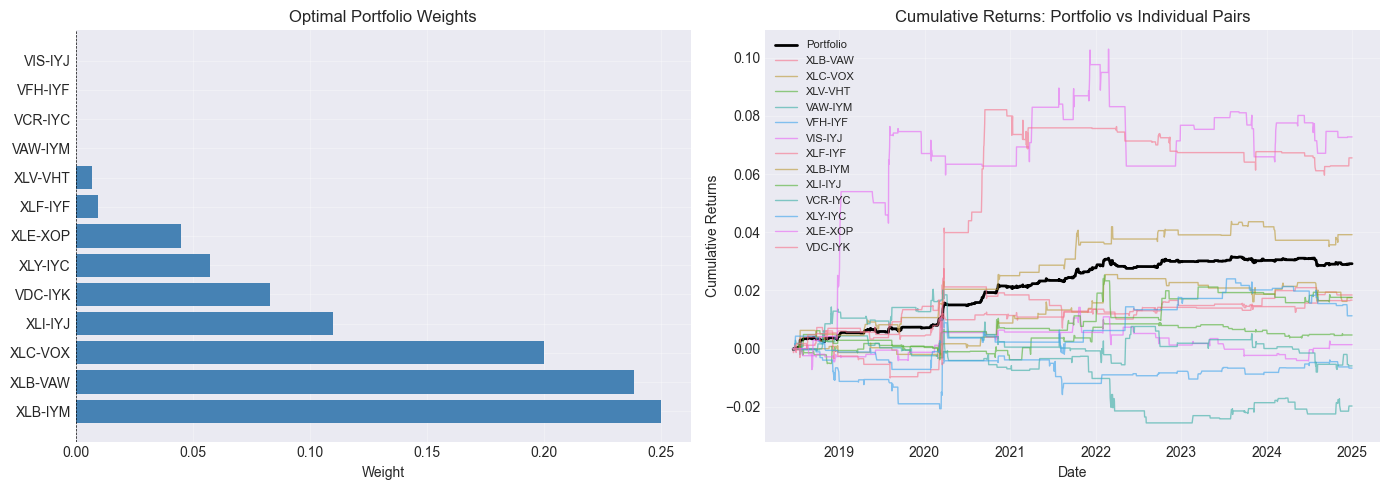

In [40]:
# Visualize portfolio weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weights bar chart
weights_df = pd.Series(optimal_weights)
weights_df = weights_df.sort_values(key=abs, ascending=False)

axes[0].barh(range(len(weights_df)), weights_df.values, color='steelblue')
axes[0].set_yticks(range(len(weights_df)))
axes[0].set_yticklabels(weights_df.index)
axes[0].set_xlabel('Weight')
axes[0].set_title('Optimal Portfolio Weights')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Portfolio returns vs individual pair returns
axes[1].plot(portfolio_returns.cumsum(), label='Portfolio', linewidth=2, color='black')
for pair_name, returns in pair_returns_dict.items():
    aligned_returns = returns.reindex(portfolio_returns.index, fill_value=0)
    axes[1].plot(aligned_returns.cumsum(), label=pair_name, alpha=0.6, linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Returns')
axes[1].set_title('Cumulative Returns: Portfolio vs Individual Pairs')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Optimize hedge ratios (Kalman filter parameters) for each pair
print("="*70)
print("Hedge Ratio Optimization (Kalman Filter Parameters)")
print("="*70)
print("\nNote: This optimization can be time-consuming. It optimizes observation_noise,")
print("state_noise, and initial_beta for each pair to maximize Sharpe ratio.\n")

# Option to skip optimization (set to True to skip)
SKIP_HEDGE_OPTIMIZATION = False

if not SKIP_HEDGE_OPTIMIZATION:
    optimized_hedge_results = {}
    
    for pair_name, pair_data in pair_data_dict.items():
        print(f"\nOptimizing hedge ratio for {pair_name}...")
        
        try:
            # Set parameter bounds for optimization
            param_bounds = {
                'observation_noise': (0.0001, 0.01),
                'state_noise': (0.00001, 0.001),
                'initial_beta': (0.5, 1.5)
            }
            
            # Optimize
            hedge_opt_result = optimize_hedge_ratios(
                pair_data,
                kalman_config=config.KALMAN_CONFIG,
                objective='sharpe',
                param_bounds=param_bounds,
                method='fast',
                use_subset=True,
                subset_size=1000
            )
            
            optimized_hedge_results[pair_name] = hedge_opt_result
            
            # Display results
            opt_config = hedge_opt_result['optimal_config']
            metrics = hedge_opt_result['metrics']
            
            print(f"  Optimal parameters:")
            print(f"    observation_noise: {opt_config['observation_noise']:.6f}")
            print(f"    state_noise: {opt_config['state_noise']:.6f}")
            print(f"    initial_beta: {opt_config['initial_beta']:.4f}")
            print(f"  Performance: Sharpe={metrics['sharpe_ratio']:.3f}, "
                  f"AnnRet={metrics['annualized_return']:.2%}")
            
        except Exception as e:
            print(f"  ✗ Error optimizing {pair_name}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    print(f"\n✓ Optimized hedge ratios for {len(optimized_hedge_results)} pairs")
    
    # Compare original vs optimized
    print("\n" + "="*70)
    print("Comparison: Original vs Optimized Hedge Ratios")
    print("="*70)
    
    comparison_data = []
    for pair_name in pair_results.keys():
        if pair_name in optimized_hedge_results:
            orig_metrics = compute_performance_metrics(pair_results[pair_name]['strategy_returns'])
            opt_metrics = optimized_hedge_results[pair_name]['metrics']
            
            comparison_data.append({
                'Pair': pair_name,
                'Original_Sharpe': orig_metrics.get('sharpe_ratio', 0),
                'Optimized_Sharpe': opt_metrics.get('sharpe_ratio', 0),
                'Original_AnnRet': orig_metrics.get('annualized_return', 0),
                'Optimized_AnnRet': opt_metrics.get('annualized_return', 0),
                'Improvement_Sharpe': opt_metrics.get('sharpe_ratio', 0) - orig_metrics.get('sharpe_ratio', 0)
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        display(comparison_df)
        
        # Store optimized results
        for pair_name, result in optimized_hedge_results.items():
            pair_results[pair_name]['optimized_hedge'] = result
else:
    print("Skipping hedge ratio optimization (SKIP_HEDGE_OPTIMIZATION=True)")


Hedge Ratio Optimization (Kalman Filter Parameters)

Note: This optimization can be time-consuming. It optimizes observation_noise,
state_noise, and initial_beta for each pair to maximize Sharpe ratio.


Optimizing hedge ratio for XLRE-IYR...
  ✗ Error optimizing XLRE-IYR: setting an array element with a sequence.

Optimizing hedge ratio for XLRE-VNQ...


TypeError: float() argument must be a string or a real number, not 'NAType'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/tt/cvw7nz6j26z97xt52x5sh3m80000gn/T/ipykernel_28009/4126646005.py", line 26, in <module>
    hedge_opt_result = optimize_hedge_ratios(
        pair_data,
    ...<5 lines>...
        subset_size=1000
    )
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/portfolio_optimization.py", line 320, in optimize_hedge_ratios
    kalman_result = estimate_hedge_ratio_kalman(pair_data, optimal_config)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 278, in estimate_hedge_ratio_kalman
    result = kf.smooth(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 185, in smooth
    filter_result = self.filter(y, x)


  ✗ Error optimizing XLRE-VNQ: setting an array element with a sequence.

Optimizing hedge ratio for XLB-VAW...


TypeError: float() argument must be a string or a real number, not 'NAType'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/tt/cvw7nz6j26z97xt52x5sh3m80000gn/T/ipykernel_28009/4126646005.py", line 26, in <module>
    hedge_opt_result = optimize_hedge_ratios(
        pair_data,
    ...<5 lines>...
        subset_size=1000
    )
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/portfolio_optimization.py", line 320, in optimize_hedge_ratios
    kalman_result = estimate_hedge_ratio_kalman(pair_data, optimal_config)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 278, in estimate_hedge_ratio_kalman
    result = kf.smooth(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 185, in smooth
    filter_result = self.filter(y, x)


  Optimal parameters:
    observation_noise: 0.000100
    state_noise: 0.000753
    initial_beta: 0.5000
  Performance: Sharpe=0.710, AnnRet=0.34%

Optimizing hedge ratio for XLC-VOX...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.001000
    initial_beta: 0.5000
  Performance: Sharpe=0.853, AnnRet=0.49%

Optimizing hedge ratio for XLV-VHT...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.000010
    initial_beta: 1.0000
  Performance: Sharpe=0.330, AnnRet=0.14%

Optimizing hedge ratio for VAW-IYM...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.001000
    initial_beta: 0.5000
  Performance: Sharpe=0.511, AnnRet=0.37%

Optimizing hedge ratio for VFH-IYF...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.000010
    initial_beta: 0.5000
  Performance: Sharpe=0.113, AnnRet=0.04%

Optimizing hedge ratio for VIS-IYJ...
  Optimal parameters:
    observation_noise: 0.007525
    state_noise:

,Pair,Original_Sharpe,Optimized_Sharpe,Original_AnnRet,Optimized_AnnRet,Improvement_Sharpe
0,XLB-VAW,0.430466,0.710226,0.001936,0.003368,0.279760
1,XLC-VOX,0.506062,0.852775,0.002674,0.004887,0.346713
2,XLV-VHT,0.212803,0.330324,0.000878,0.001434,0.117522
3,VAW-IYM,-0.043613,0.511327,-0.000286,0.003662,0.554940
4,VFH-IYF,0.038810,0.113451,0.000213,0.000430,0.074641
5,VIS-IYJ,-0.095645,0.234002,-0.000475,0.001214,0.329648
6,XLF-IYF,0.310320,0.358743,0.002087,0.002108,0.048422
7,XLB-IYM,0.683496,0.712938,0.004972,0.004819,0.029442
8,XLI-IYJ,0.198762,0.569297,0.001191,0.002782,0.370535
9,VCR-IYC,-0.002500,0.585671,-0.000018,0.004123,0.588171


Recomputing Portfolio with Optimized Hedge Ratios

Optimal Portfolio Weights (with optimized hedge ratios):
----------------------------------------------------------------------
  XLB-IYM     :   0.1658 ( 16.58%)
  XLC-VOX     :   0.1268 ( 12.68%)
  XLI-IYJ     :   0.1258 ( 12.58%)
  VCR-IYC     :   0.1075 ( 10.75%)
  VFH-IYF     :   0.0962 (  9.62%)
  XLB-VAW     :   0.0935 (  9.35%)
  VAW-IYM     :   0.0776 (  7.76%)
  VIS-IYJ     :   0.0500 (  5.00%)
  XLY-IYC     :   0.0419 (  4.19%)
  VDC-IYK     :   0.0415 (  4.15%)
  XLE-XOP     :   0.0303 (  3.03%)
  XLF-IYF     :   0.0238 (  2.38%)
  XLV-VHT     :   0.0193 (  1.93%)

Portfolio Performance Metrics (with optimized hedge ratios):
----------------------------------------------------------------------
  annualized_return        :     0.0059 (0.59%)
  sharpe_ratio             :     2.3434 (234.34%)
  total_return             :     0.0390 (3.90%)
  n_periods                : 1645

Comparison: Original Portfolio vs Optimized Portfoli

,Original,Optimized
annualized_return,0.004473,0.005861
annualized_volatility,0.003079,0.002501
sharpe_ratio,1.452633,2.343360
total_return,0.029598,0.038982
max_drawdown,-0.003517,-0.001868
n_periods,1645.000000,1645.000000



Portfolio Returns Visualization


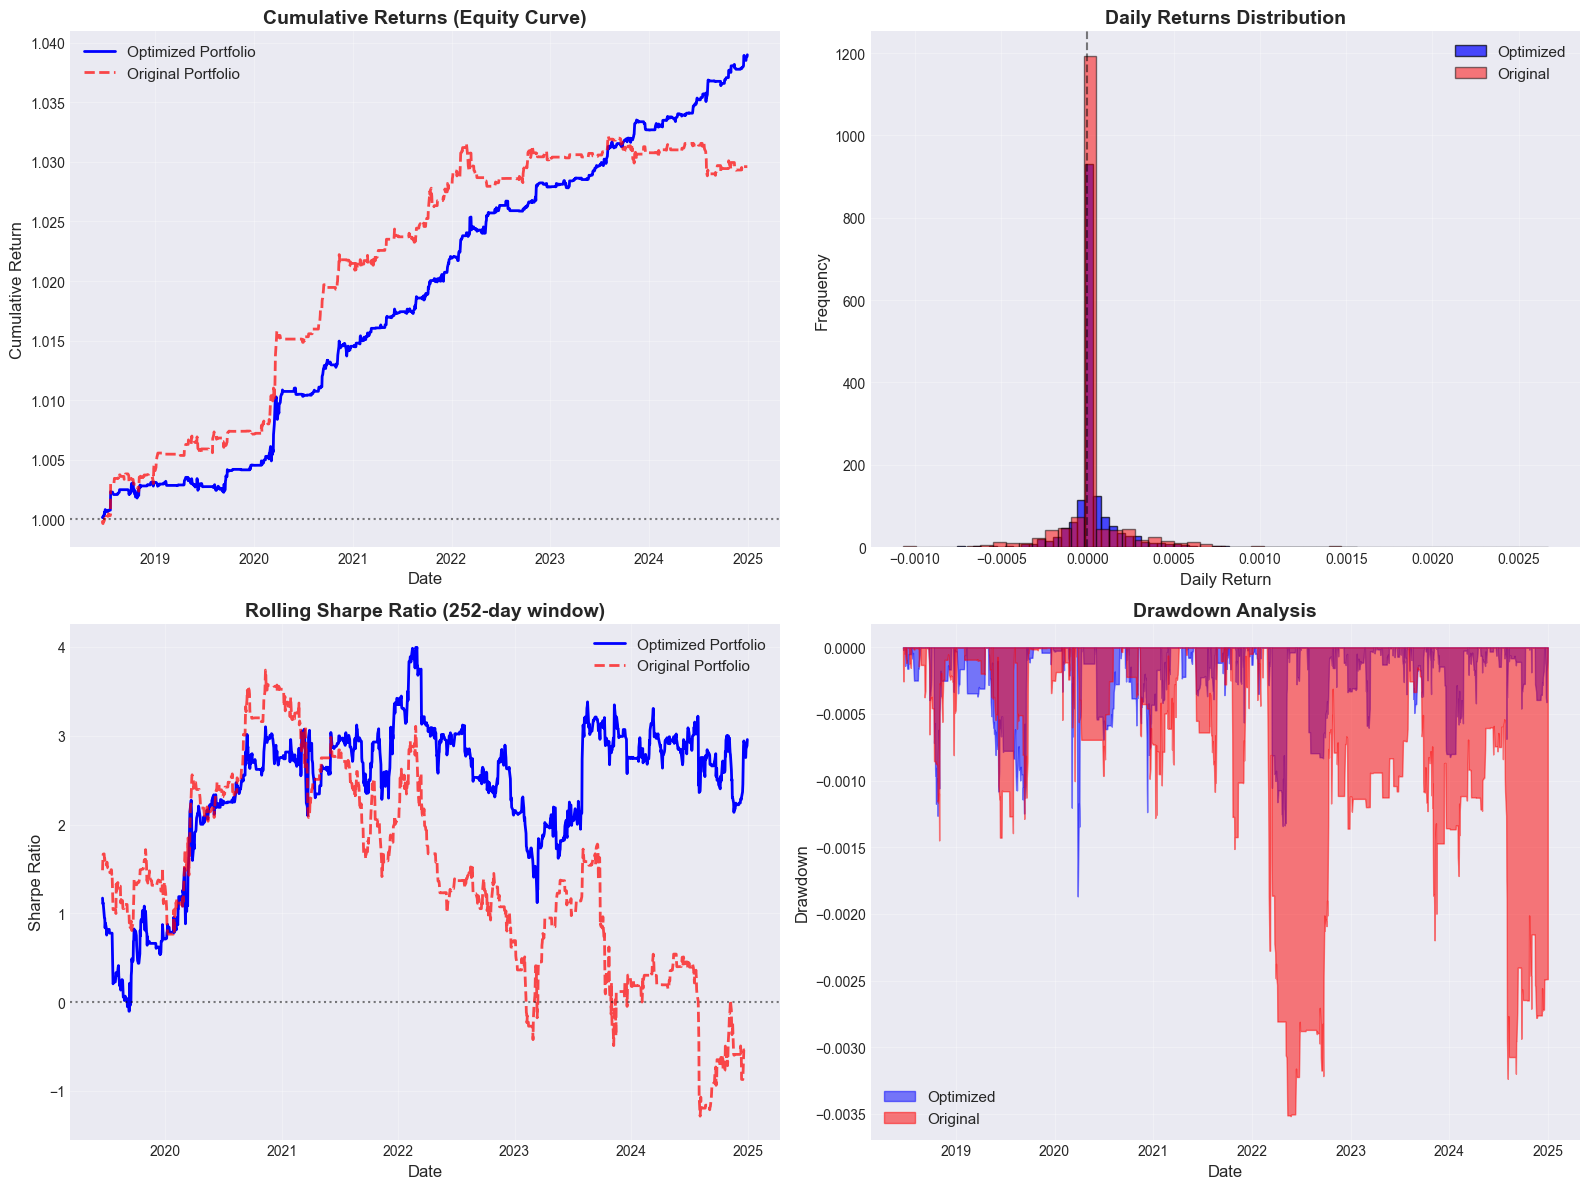


Return Statistics Summary:
----------------------------------------------------------------------
Optimized Portfolio:
  Total Return: 3.90%
  Annualized Return: 0.59%
  Annualized Volatility: 0.25%
  Sharpe Ratio: 2.3434
  Max Drawdown: -0.19%

Original Portfolio:
  Total Return: 2.96%
  Annualized Return: 0.45%
  Annualized Volatility: 0.31%
  Sharpe Ratio: 1.4526
  Max Drawdown: -0.35%


In [ ]:
# Recompute portfolio with optimized hedge ratios (if optimization was run)
if not SKIP_HEDGE_OPTIMIZATION and 'optimized_hedge_results' in locals():
    print("="*70)
    print("Recomputing Portfolio with Optimized Hedge Ratios")
    print("="*70)
    
    # Extract optimized strategy returns
    optimized_pair_returns = {}
    for pair_name, result in optimized_hedge_results.items():
        optimized_pair_returns[pair_name] = result['strategy_returns']
    
    # Optimize portfolio weights again with optimized returns
    opt_result_optimized = optimize_portfolio_weights(
        optimized_pair_returns,
        objective='sharpe',
        constraints=weight_constraints,
        method='SLSQP'
    )
    
    optimal_weights_optimized = opt_result_optimized['weights']
    portfolio_returns_optimized = opt_result_optimized['portfolio_returns']
    portfolio_metrics_optimized = opt_result_optimized['metrics']
    
    print("\nOptimal Portfolio Weights (with optimized hedge ratios):")
    print("-"*70)
    for pair_name, weight in sorted(optimal_weights_optimized.items(), key=lambda x: abs(x[1]), reverse=True):
        print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")
    
    print("\nPortfolio Performance Metrics (with optimized hedge ratios):")
    print("-"*70)
    for metric, value in portfolio_metrics_optimized.items():
        if isinstance(value, float):
            if 'return' in metric.lower() or 'sharpe' in metric.lower():
                print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value}")
    
    # Compare
    print("\n" + "="*70)
    print("Comparison: Original Portfolio vs Optimized Portfolio")
    print("="*70)
    
    comparison = pd.DataFrame({
        'Original': portfolio_metrics,
        'Optimized': portfolio_metrics_optimized
    })
    display(comparison)
    
    # Store optimized portfolio results
    portfolio_results['optimized_hedge_weights'] = optimal_weights_optimized
    portfolio_results['optimized_hedge_returns'] = portfolio_returns_optimized
    portfolio_results['optimized_hedge_metrics'] = portfolio_metrics_optimized
    
    # Plot portfolio returns
    print("\n" + "="*70)
    print("Portfolio Returns Visualization")
    print("="*70)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Cumulative Returns (Equity Curve)
    cumulative_returns_optimized = (1 + portfolio_returns_optimized).cumprod()
    cumulative_returns_original = (1 + portfolio_returns).cumprod()
    
    axes[0, 0].plot(cumulative_returns_optimized.index, cumulative_returns_optimized.values, 
                    label='Optimized Portfolio', linewidth=2, color='blue')
    axes[0, 0].plot(cumulative_returns_original.index, cumulative_returns_original.values, 
                    label='Original Portfolio', linewidth=2, color='red', alpha=0.7, linestyle='--')
    axes[0, 0].axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
    axes[0, 0].set_title('Cumulative Returns (Equity Curve)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Date', fontsize=12)
    axes[0, 0].set_ylabel('Cumulative Return', fontsize=12)
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Daily Returns Distribution
    axes[0, 1].hist(portfolio_returns_optimized.values, bins=50, alpha=0.7, 
                     label='Optimized', color='blue', edgecolor='black')
    axes[0, 1].hist(portfolio_returns.values, bins=50, alpha=0.5, 
                     label='Original', color='red', edgecolor='black')
    axes[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 1].set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Daily Return', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Rolling Sharpe Ratio (252-day window)
    rolling_window = min(252, len(portfolio_returns_optimized))
    if rolling_window > 60:  # Only plot if we have enough data
        rolling_sharpe_optimized = portfolio_returns_optimized.rolling(window=rolling_window).mean() / \
                                   portfolio_returns_optimized.rolling(window=rolling_window).std() * np.sqrt(252)
        rolling_sharpe_original = portfolio_returns.rolling(window=rolling_window).mean() / \
                                 portfolio_returns.rolling(window=rolling_window).std() * np.sqrt(252)
        
        axes[1, 0].plot(rolling_sharpe_optimized.index, rolling_sharpe_optimized.values, 
                        label='Optimized Portfolio', linewidth=2, color='blue')
        axes[1, 0].plot(rolling_sharpe_original.index, rolling_sharpe_original.values, 
                        label='Original Portfolio', linewidth=2, color='red', alpha=0.7, linestyle='--')
        axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.5)
        axes[1, 0].set_title(f'Rolling Sharpe Ratio ({rolling_window}-day window)', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Date', fontsize=12)
        axes[1, 0].set_ylabel('Sharpe Ratio', fontsize=12)
        axes[1, 0].legend(fontsize=11)
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Insufficient data for rolling Sharpe', 
                        ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
    
    # 4. Drawdown Analysis
    equity_optimized = cumulative_returns_optimized
    running_max_optimized = equity_optimized.expanding().max()
    drawdown_optimized = (equity_optimized - running_max_optimized) / running_max_optimized
    
    equity_original = cumulative_returns_original
    running_max_original = equity_original.expanding().max()
    drawdown_original = (equity_original - running_max_original) / running_max_original
    
    # Clean data for plotting
    dd_optimized_clean = drawdown_optimized.dropna().astype(float)
    dd_original_clean = drawdown_original.dropna().astype(float)
    
    axes[1, 1].fill_between(dd_optimized_clean.index, dd_optimized_clean.values, 0, 
                            alpha=0.5, label='Optimized', color='blue')
    axes[1, 1].fill_between(dd_original_clean.index, dd_original_clean.values, 0, 
                            alpha=0.5, label='Original', color='red')
    axes[1, 1].set_title('Drawdown Analysis', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date', fontsize=12)
    axes[1, 1].set_ylabel('Drawdown', fontsize=12)
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nReturn Statistics Summary:")
    print("-"*70)
    print(f"Optimized Portfolio:")
    print(f"  Total Return: {portfolio_metrics_optimized.get('total_return', 0)*100:.2f}%")
    print(f"  Annualized Return: {portfolio_metrics_optimized.get('annualized_return', 0)*100:.2f}%")
    print(f"  Annualized Volatility: {portfolio_metrics_optimized.get('annualized_volatility', 0)*100:.2f}%")
    print(f"  Sharpe Ratio: {portfolio_metrics_optimized.get('sharpe_ratio', 0):.4f}")
    print(f"  Max Drawdown: {portfolio_metrics_optimized.get('max_drawdown', 0)*100:.2f}%")
    print(f"\nOriginal Portfolio:")
    print(f"  Total Return: {portfolio_metrics.get('total_return', 0)*100:.2f}%")
    print(f"  Annualized Return: {portfolio_metrics.get('annualized_return', 0)*100:.2f}%")
    print(f"  Annualized Volatility: {portfolio_metrics.get('annualized_volatility', 0)*100:.2f}%")
    print(f"  Sharpe Ratio: {portfolio_metrics.get('sharpe_ratio', 0):.4f}")
    print(f"  Max Drawdown: {portfolio_metrics.get('max_drawdown', 0)*100:.2f}%")
else:
    print("Skipping portfolio recomputation (hedge ratio optimization was skipped)")


Generating Individual Visualizations for Optimized Portfolio


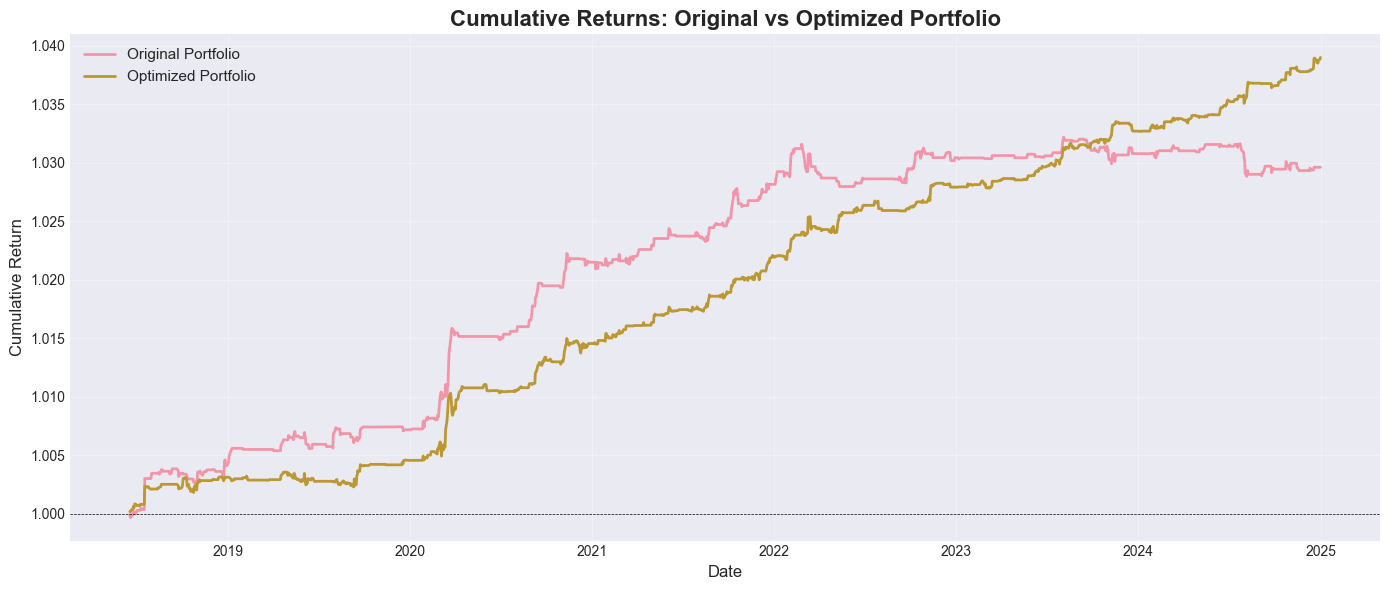

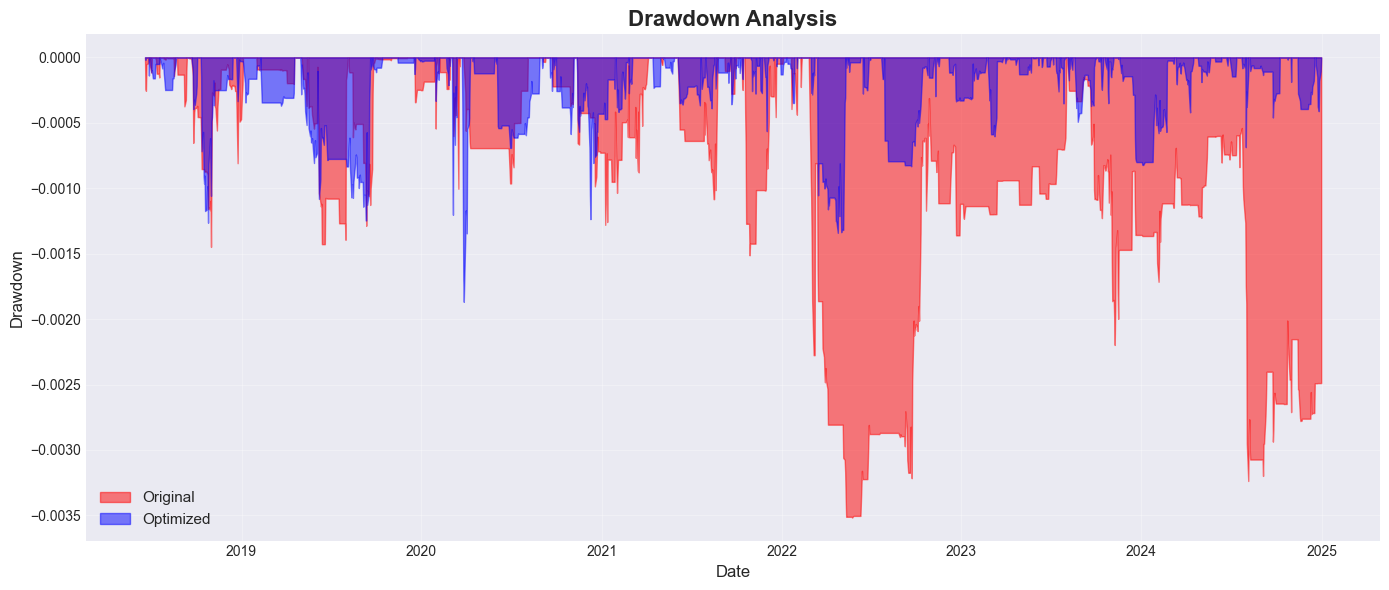

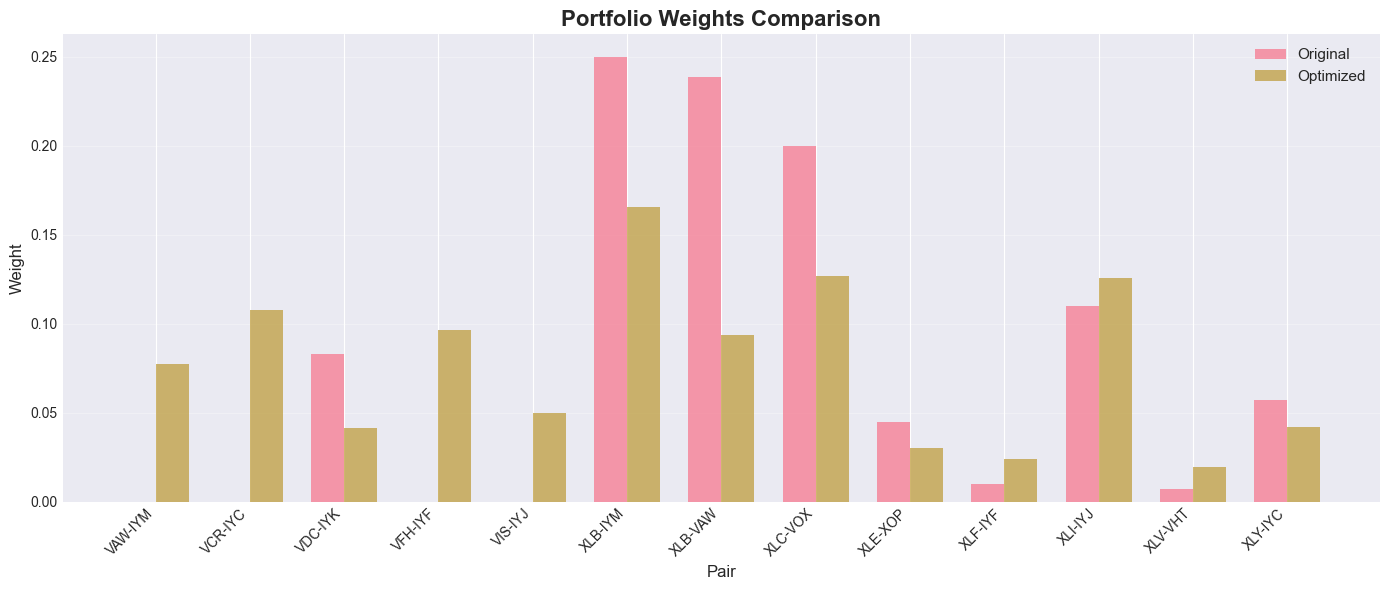

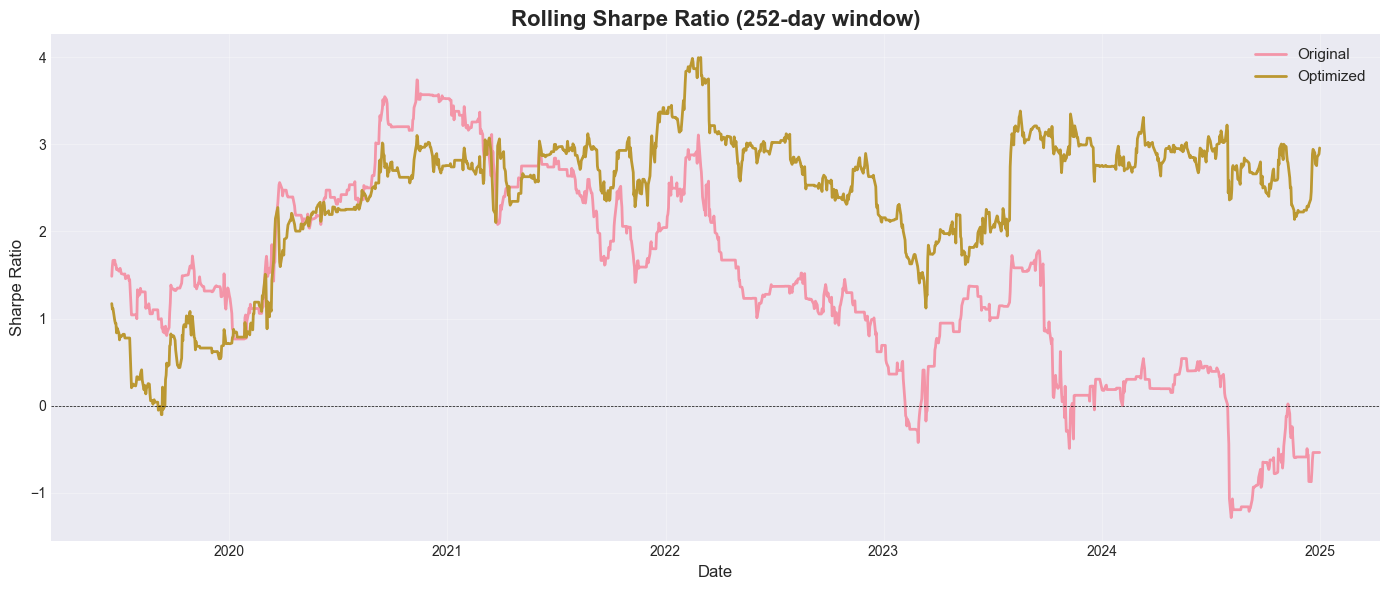

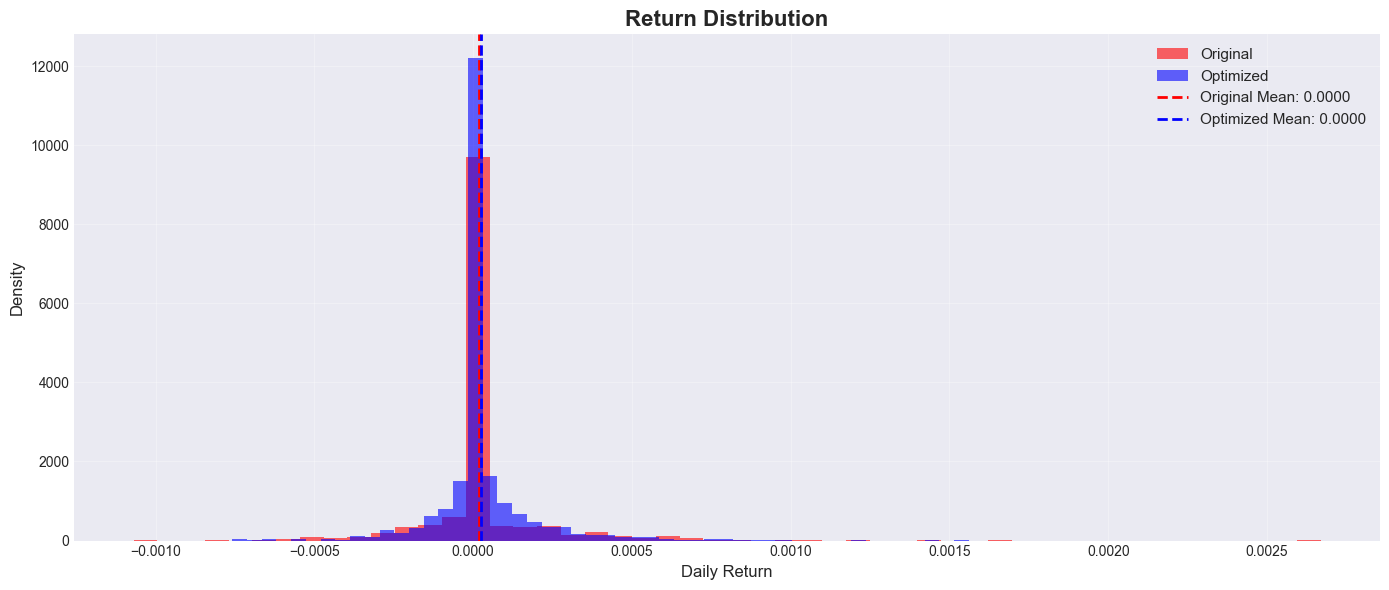

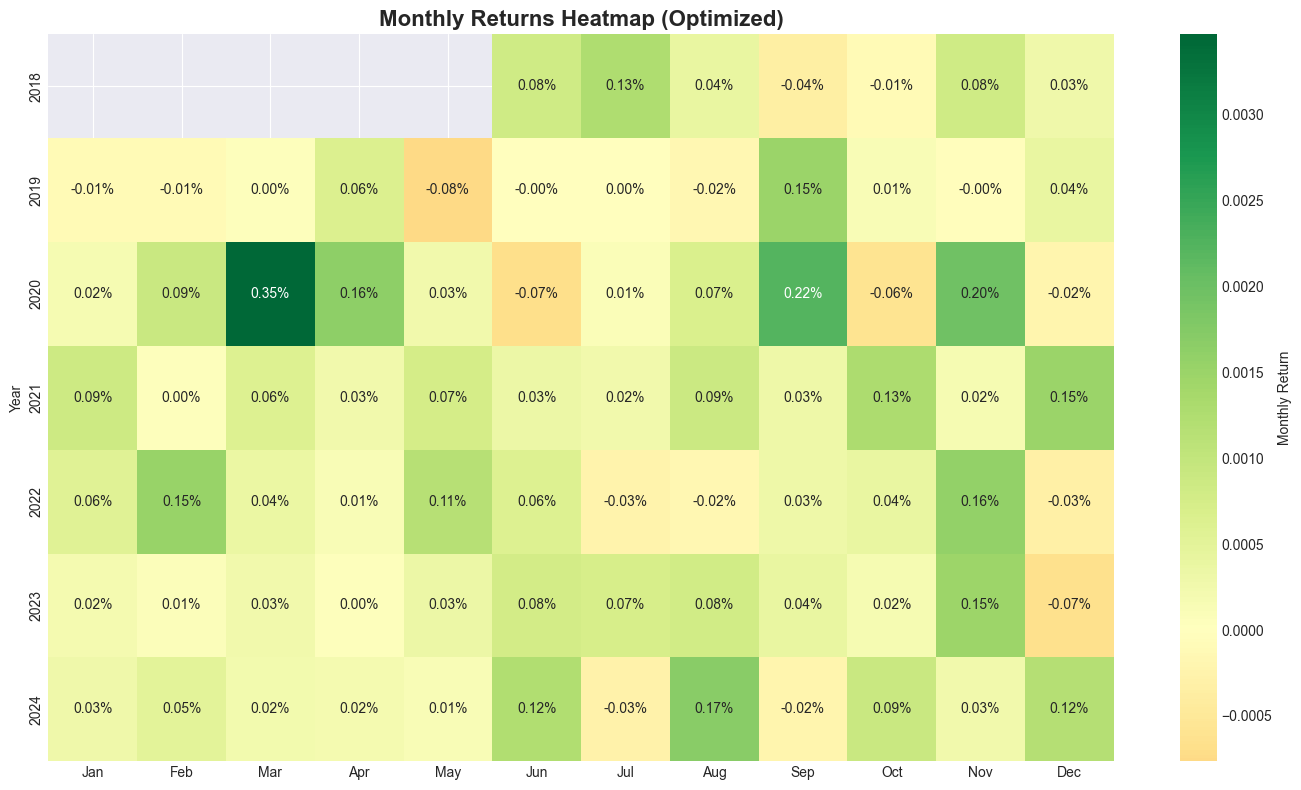

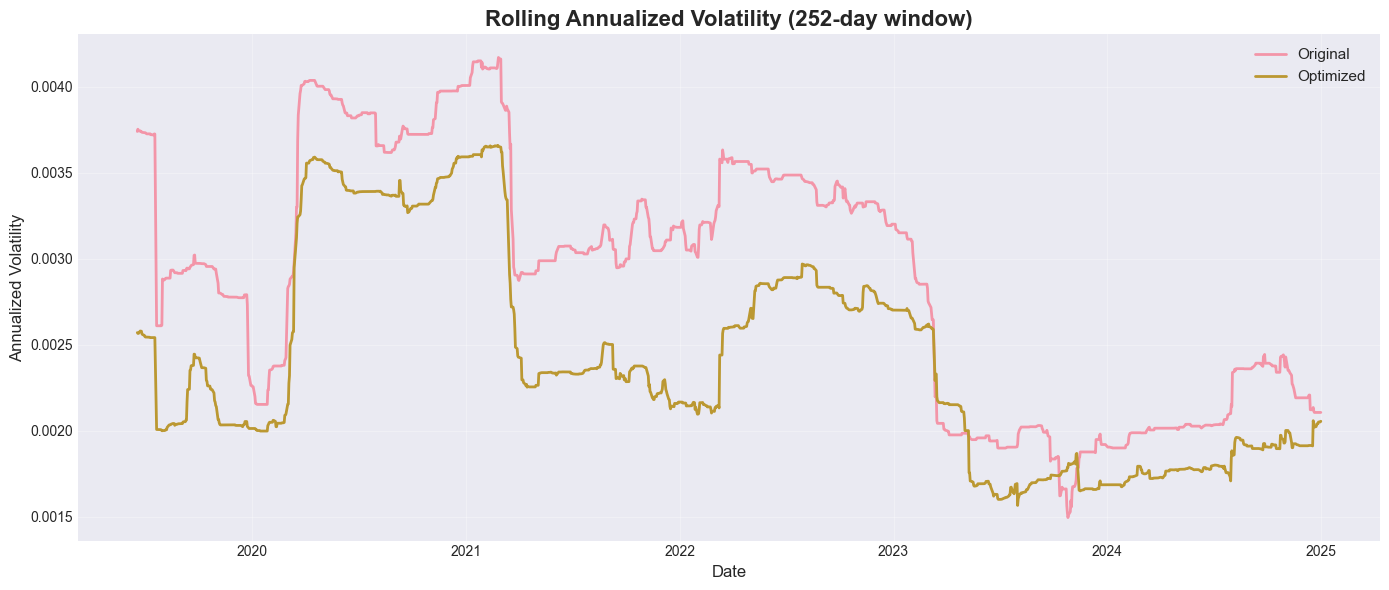

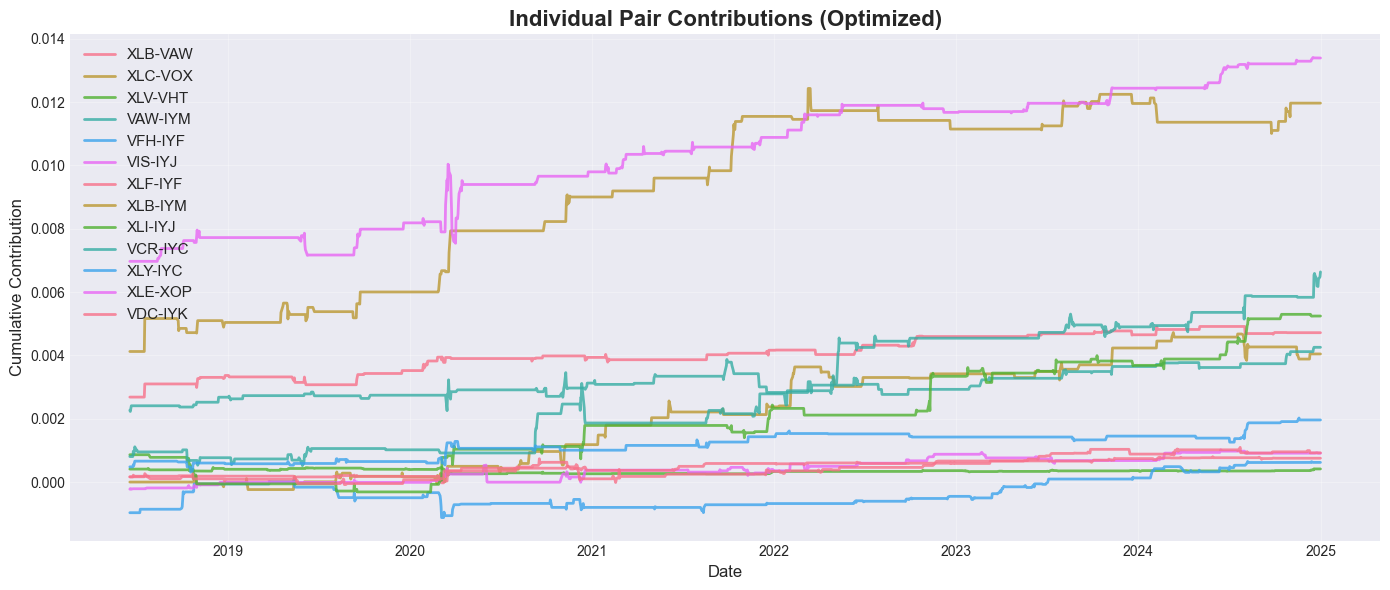

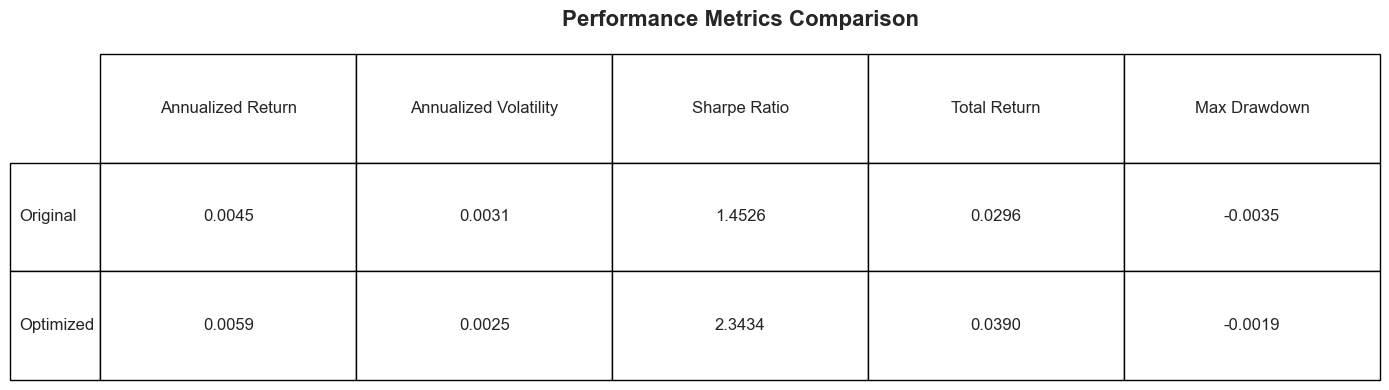

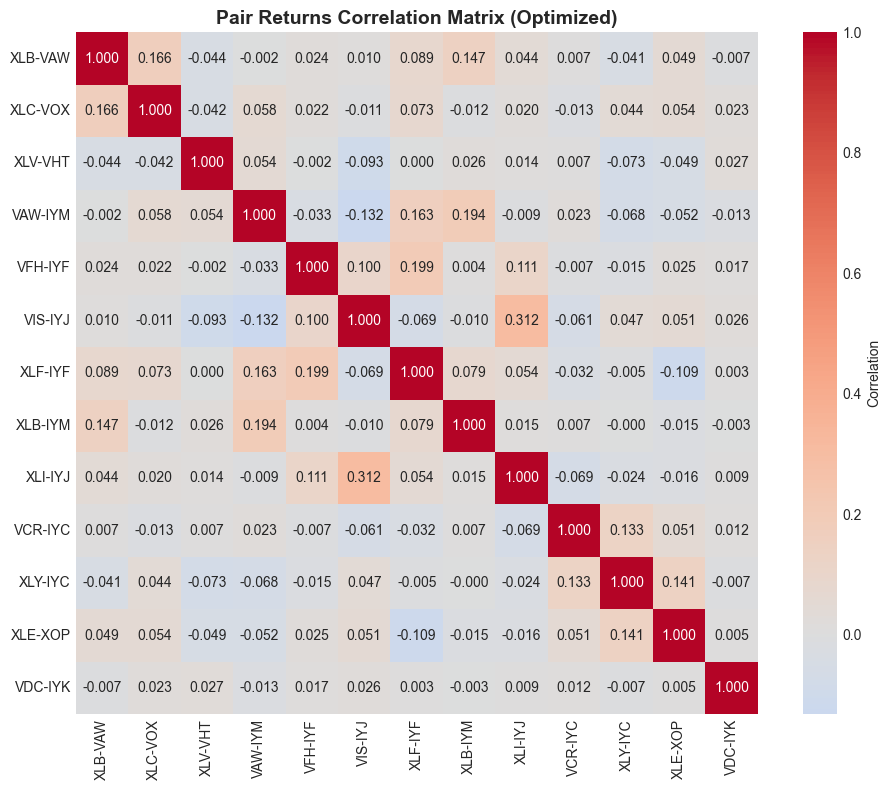


✓ All individual visualizations generated!


In [43]:
# Individual Plots for Optimized Portfolio (Vertical Stack - Bigger Graphs)
if not SKIP_HEDGE_OPTIMIZATION and 'opt_result_optimized' in locals():
    print("="*70)
    print("Generating Individual Visualizations for Optimized Portfolio")
    print("="*70)
    
    # Extract data
    opt_returns = portfolio_returns_optimized
    opt_weights = optimal_weights_optimized
    opt_metrics = portfolio_metrics_optimized
    
    # Original portfolio for comparison
    orig_returns = portfolio_returns
    orig_weights = optimal_weights
    orig_metrics = portfolio_metrics
    
    window = 252
    
    # 1. Cumulative Returns Comparison
    plt.figure(figsize=(14, 6))
    cum_ret_orig = (1 + orig_returns).cumprod()
    cum_ret_opt = (1 + opt_returns).cumprod()
    plt.plot(cum_ret_orig.index, cum_ret_orig.values, label='Original Portfolio', linewidth=2, alpha=0.7)
    plt.plot(cum_ret_opt.index, cum_ret_opt.values, label='Optimized Portfolio', linewidth=2)
    plt.title('Cumulative Returns: Original vs Optimized Portfolio', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Return', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    # 2. Drawdown Analysis
    plt.figure(figsize=(14, 6))
    equity_orig = (1 + orig_returns).cumprod()
    equity_opt = (1 + opt_returns).cumprod()
    running_max_orig = equity_orig.expanding().max()
    running_max_opt = equity_opt.expanding().max()
    dd_orig = (equity_orig - running_max_orig) / running_max_orig
    dd_opt = (equity_opt - running_max_opt) / running_max_opt
    
    # Ensure numeric values and proper index handling
    dd_orig_clean = dd_orig.dropna()
    dd_opt_clean = dd_opt.dropna()
    
    plt.fill_between(dd_orig_clean.index, dd_orig_clean.values.astype(float), 0, alpha=0.5, label='Original', color='red')
    plt.fill_between(dd_opt_clean.index, dd_opt_clean.values.astype(float), 0, alpha=0.5, label='Optimized', color='blue')
    plt.title('Drawdown Analysis', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Drawdown', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Portfolio Weights Comparison
    plt.figure(figsize=(14, 6))
    pairs = sorted(set(list(orig_weights.keys()) + list(opt_weights.keys())))
    orig_vals = [orig_weights.get(p, 0) for p in pairs]
    opt_vals = [opt_weights.get(p, 0) for p in pairs]
    x = np.arange(len(pairs))
    width = 0.35
    plt.bar(x - width/2, orig_vals, width, label='Original', alpha=0.7)
    plt.bar(x + width/2, opt_vals, width, label='Optimized', alpha=0.7)
    plt.title('Portfolio Weights Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Pair', fontsize=12)
    plt.ylabel('Weight', fontsize=12)
    plt.xticks(x, pairs, rotation=45, ha='right')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    # 4. Rolling Sharpe Ratio
    plt.figure(figsize=(14, 6))
    rolling_sharpe_orig = orig_returns.rolling(window=window).apply(
        lambda x: x.mean() * 252 / (x.std() * np.sqrt(252)) if x.std() > 0 else 0
    )
    rolling_sharpe_opt = opt_returns.rolling(window=window).apply(
        lambda x: x.mean() * 252 / (x.std() * np.sqrt(252)) if x.std() > 0 else 0
    )
    plt.plot(rolling_sharpe_orig.index, rolling_sharpe_orig.values, label='Original', alpha=0.7, linewidth=2)
    plt.plot(rolling_sharpe_opt.index, rolling_sharpe_opt.values, label='Optimized', linewidth=2)
    plt.title(f'Rolling Sharpe Ratio ({window}-day window)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sharpe Ratio', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    # 5. Return Distribution
    plt.figure(figsize=(14, 6))
    plt.hist(orig_returns.dropna(), bins=50, alpha=0.6, label='Original', density=True, color='red')
    plt.hist(opt_returns.dropna(), bins=50, alpha=0.6, label='Optimized', density=True, color='blue')
    plt.axvline(orig_returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Original Mean: {orig_returns.mean():.4f}')
    plt.axvline(opt_returns.mean(), color='blue', linestyle='--', linewidth=2, label=f'Optimized Mean: {opt_returns.mean():.4f}')
    plt.title('Return Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Daily Return', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 6. Monthly Returns Heatmap (Optimized)
    plt.figure(figsize=(14, 8))
    opt_monthly = opt_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
    opt_monthly_df = pd.DataFrame({
        'Year': opt_monthly.index.year,
        'Month': opt_monthly.index.month,
        'Return': opt_monthly.values
    }).pivot(index='Year', columns='Month', values='Return')
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    opt_monthly_df.columns = [month_names.get(col, col) for col in opt_monthly_df.columns]
    sns.heatmap(opt_monthly_df, annot=True, fmt='.2%', cmap='RdYlGn', center=0, 
                cbar_kws={'label': 'Monthly Return'}, xticklabels=True, yticklabels=True)
    plt.title('Monthly Returns Heatmap (Optimized)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 7. Rolling Volatility
    plt.figure(figsize=(14, 6))
    rolling_vol_orig = orig_returns.rolling(window=window).std() * np.sqrt(252)
    rolling_vol_opt = opt_returns.rolling(window=window).std() * np.sqrt(252)
    plt.plot(rolling_vol_orig.index, rolling_vol_orig.values, label='Original', alpha=0.7, linewidth=2)
    plt.plot(rolling_vol_opt.index, rolling_vol_opt.values, label='Optimized', linewidth=2)
    plt.title(f'Rolling Annualized Volatility ({window}-day window)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Annualized Volatility', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 8. Individual Pair Contributions (Optimized)
    plt.figure(figsize=(14, 6))
    pair_contributions = {}
    for pair_name, weight in opt_weights.items():
        if pair_name in optimized_pair_returns:
            pair_contributions[pair_name] = (optimized_pair_returns[pair_name] * weight).cumsum()
    
    for pair_name, contrib in pair_contributions.items():
        aligned = contrib.reindex(opt_returns.index, fill_value=0)
        plt.plot(aligned.index, aligned.values, label=pair_name, alpha=0.8, linewidth=2)
    plt.title('Individual Pair Contributions (Optimized)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Contribution', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 9. Performance Metrics Comparison Table
    plt.figure(figsize=(14, 4))
    plt.axis('off')
    metrics_comparison = pd.DataFrame({
        'Original': orig_metrics,
        'Optimized': opt_metrics
    }).T
    display_metrics = {}
    for metric in ['annualized_return', 'annualized_volatility', 'sharpe_ratio', 
                   'total_return', 'max_drawdown']:
        if metric in metrics_comparison.columns:
            display_metrics[metric.replace('_', ' ').title()] = metrics_comparison[metric]
    
    display_df = pd.DataFrame(display_metrics)
    table = plt.table(cellText=[[f"{val:.4f}" if isinstance(val, float) else str(val) 
                                  for val in row] for row in display_df.values],
                      rowLabels=display_df.index,
                      colLabels=display_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2.5)
    plt.title('Performance Metrics Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    opt_pair_returns_df = pd.DataFrame(optimized_pair_returns)
    opt_corr = opt_pair_returns_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(opt_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                square=True, cbar_kws={'label': 'Correlation'})
    plt.title('Pair Returns Correlation Matrix (Optimized)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ All individual visualizations generated!")
    
else:
    print("Optimized portfolio results not available. Run hedge ratio optimization first.")

## 8. Transaction Cost Analysis {#transaction_costs}

Recompute strategy returns with transaction costs and reoptimize portfolio. Transaction costs are adjustable to find the optimal balance.


In [44]:
# Function to compute strategy returns with transaction costs
def compute_strategy_returns_with_costs(signals, pair_data, transaction_cost_bps=10, spread_cost_bps=5):
    """
    Compute strategy returns including transaction costs.
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: position_size_A, position_size_B
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
    transaction_cost_bps : float
        Transaction cost in basis points (default: 10 bps = 0.1%)
    spread_cost_bps : float
        Spread cost in basis points (default: 5 bps = 0.05%)
    
    Returns:
    --------
    pd.Series : Strategy returns with transaction costs
    """
    # Convert bps to decimal
    transaction_cost = transaction_cost_bps / 10000
    spread_cost = spread_cost_bps / 10000
    
    # Align data on common dates
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get position sizes and returns
    pos_a = signals.loc[common_idx, 'position_size_A']
    pos_b = signals.loc[common_idx, 'position_size_B']
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Compute strategy returns with transaction costs
    strategy_returns = pd.Series(index=common_idx, data=0.0)
    
    prev_pos_a = 0.0
    prev_pos_b = 0.0
    
    for i, date in enumerate(common_idx):
        curr_pos_a = pos_a.loc[date] if not pd.isna(pos_a.loc[date]) else 0.0
        curr_pos_b = pos_b.loc[date] if not pd.isna(pos_b.loc[date]) else 0.0
        
        # Position change (turnover)
        delta_a = curr_pos_a - prev_pos_a
        delta_b = curr_pos_b - prev_pos_b
        
        # Transaction costs (only on position changes)
        turnover_a = abs(delta_a)
        turnover_b = abs(delta_b)
        total_cost = (turnover_a + turnover_b) * (transaction_cost + spread_cost)
        
        # P&L from positions (using previous period's positions)
        if i > 0:
            pnl_from_positions = (
                prev_pos_a * returns_a.loc[date] +
                prev_pos_b * returns_b.loc[date]
            )
        else:
            pnl_from_positions = 0.0
        
        # Net P&L (normalized by notional)
        notional = abs(curr_pos_a) + abs(curr_pos_b)
        prev_notional = abs(prev_pos_a) + abs(prev_pos_b) if i > 0 else notional
        
        if prev_notional > 0:
            strategy_returns.loc[date] = (pnl_from_positions - total_cost) / prev_notional
        else:
            strategy_returns.loc[date] = 0.0
        
        prev_pos_a = curr_pos_a
        prev_pos_b = curr_pos_b
    
    return strategy_returns

print("✓ Transaction cost function defined")


✓ Transaction cost function defined


In [45]:
# Adjustable Transaction Cost Parameters
print("="*70)
print("Transaction Cost Configuration")
print("="*70)

# Transaction cost parameters (adjustable)
TRANSACTION_COST_BPS = 10  # Total transaction cost in basis points (default: 10 bps = 0.1%)
SPREAD_COST_BPS = 5        # Bid-ask spread cost in basis points (default: 5 bps = 0.05%)

# Total round-trip cost
TOTAL_COST_BPS = TRANSACTION_COST_BPS + SPREAD_COST_BPS * 2  # Both sides

print(f"\nTransaction Cost Settings:")
print(f"  Transaction Cost: {TRANSACTION_COST_BPS} bps ({TRANSACTION_COST_BPS/100:.2f}%)")
print(f"  Spread Cost (per side): {SPREAD_COST_BPS} bps ({SPREAD_COST_BPS/100:.2f}%)")
print(f"  Total Round-Trip Cost: {TOTAL_COST_BPS} bps ({TOTAL_COST_BPS/100:.2f}%)")
print(f"\n💡 Adjust TRANSACTION_COST_BPS and SPREAD_COST_BPS above to test different cost scenarios")


Transaction Cost Configuration

Transaction Cost Settings:
  Transaction Cost: 10 bps (0.10%)
  Spread Cost (per side): 5 bps (0.05%)
  Total Round-Trip Cost: 20 bps (0.20%)

💡 Adjust TRANSACTION_COST_BPS and SPREAD_COST_BPS above to test different cost scenarios


In [46]:
# Recompute strategy returns with transaction costs for all pairs
print("="*70)
print("Recomputing Strategy Returns with Transaction Costs")
print("="*70)

pair_results_with_costs = {}

for pair_name, results in pair_results.items():
    print(f"\nProcessing {pair_name} with transaction costs...")
    
    try:
        signals = results['signals']
        pair_data = results['pair_data']
        
        # Compute returns with transaction costs
        strategy_returns_with_costs = compute_strategy_returns_with_costs(
            signals, 
            pair_data,
            transaction_cost_bps=TRANSACTION_COST_BPS,
            spread_cost_bps=SPREAD_COST_BPS
        )
        
        # Store results
        pair_results_with_costs[pair_name] = {
            'strategy_returns': strategy_returns_with_costs,
            'signals': signals,
            'pair_data': pair_data
        }
        
        # Compare with and without costs
        returns_no_costs = results['strategy_returns']
        ann_ret_no_costs = returns_no_costs.mean() * 252
        ann_ret_with_costs = strategy_returns_with_costs.mean() * 252
        cost_impact = ann_ret_no_costs - ann_ret_with_costs
        
        print(f"  Ann. Return (no costs): {ann_ret_no_costs:.4f} ({ann_ret_no_costs*100:.2f}%)")
        print(f"  Ann. Return (with costs): {ann_ret_with_costs:.4f} ({ann_ret_with_costs*100:.2f}%)")
        print(f"  Cost Impact: {cost_impact:.4f} ({cost_impact*100:.2f}%)")
        
    except Exception as e:
        print(f"  ✗ Error processing {pair_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Processed {len(pair_results_with_costs)}/{len(pair_results)} pairs with transaction costs")


Recomputing Strategy Returns with Transaction Costs

Processing XLB-VAW with transaction costs...
  Ann. Return (no costs): 0.0019 (0.19%)
  Ann. Return (with costs): -0.0142 (-1.42%)
  Cost Impact: 0.0161 (1.61%)

Processing XLC-VOX with transaction costs...
  Ann. Return (no costs): 0.0027 (0.27%)
  Ann. Return (with costs): -0.0136 (-1.36%)
  Cost Impact: 0.0163 (1.63%)

Processing XLV-VHT with transaction costs...
  Ann. Return (no costs): 0.0009 (0.09%)
  Ann. Return (with costs): -0.0138 (-1.38%)
  Cost Impact: 0.0147 (1.47%)

Processing VAW-IYM with transaction costs...
  Ann. Return (no costs): -0.0003 (-0.03%)
  Ann. Return (with costs): -0.0175 (-1.75%)
  Cost Impact: 0.0172 (1.72%)

Processing VFH-IYF with transaction costs...
  Ann. Return (no costs): 0.0002 (0.02%)
  Ann. Return (with costs): -0.0175 (-1.75%)
  Cost Impact: 0.0178 (1.78%)

Processing VIS-IYJ with transaction costs...
  Ann. Return (no costs): -0.0005 (-0.05%)
  Ann. Return (with costs): -0.0170 (-1.70%)
  

In [47]:
# Extract strategy returns with costs for portfolio optimization
pair_returns_with_costs = {
    pair_name: results['strategy_returns'] 
    for pair_name, results in pair_results_with_costs.items()
}

# Optimize portfolio weights with transaction costs
print("="*70)
print("Portfolio Optimization with Transaction Costs")
print("="*70)

# Use same constraints as before
opt_result_with_costs = optimize_portfolio_weights(
    pair_returns_with_costs,
    objective='sharpe',
    constraints=weight_constraints,
    method='SLSQP'
)

optimal_weights_with_costs = opt_result_with_costs['weights']
portfolio_returns_with_costs = opt_result_with_costs['portfolio_returns']
portfolio_metrics_with_costs = opt_result_with_costs['metrics']

print("\nOptimal Portfolio Weights (with transaction costs):")
print("-"*70)
for pair_name, weight in sorted(optimal_weights_with_costs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")

print("\nPortfolio Performance Metrics (with transaction costs):")
print("-"*70)
for metric, value in portfolio_metrics_with_costs.items():
    if isinstance(value, float):
        if 'return' in metric.lower() or 'sharpe' in metric.lower():
            print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value:10.4f}")
    else:
        print(f"  {metric:25s}: {value}")

# Compare with portfolio without costs
print("\n" + "="*70)
print("Comparison: Without Costs vs With Transaction Costs")
print("="*70)

comparison_metrics = pd.DataFrame({
    'Without Costs': portfolio_metrics,
    'With Costs': portfolio_metrics_with_costs
}).T

# Select key metrics for display
key_metrics = ['annualized_return', 'annualized_volatility', 'sharpe_ratio', 
               'total_return', 'max_drawdown']
display_metrics = {m.replace('_', ' ').title(): comparison_metrics[m] 
                   for m in key_metrics if m in comparison_metrics.columns}

display_df = pd.DataFrame(display_metrics)
display_df['Cost Impact (bps)'] = (display_df.iloc[0] - display_df.iloc[1]) * 10000

print("\nPerformance Comparison:")
display(display_df.style.format({
    col: '{:.4f}' if 'Impact' not in col else '{:.2f}' 
    for col in display_df.columns
}))


Portfolio Optimization with Transaction Costs

Optimal Portfolio Weights (with transaction costs):
----------------------------------------------------------------------
  XLC-VOX     :   0.2500 ( 25.00%)
  XLE-XOP     :   0.2500 ( 25.00%)
  VDC-IYK     :   0.2500 ( 25.00%)
  XLB-IYM     :   0.2500 ( 25.00%)
  VAW-IYM     :   0.0000 (  0.00%)
  VIS-IYJ     :   0.0000 (  0.00%)
  XLB-VAW     :   0.0000 (  0.00%)
  XLI-IYJ     :   0.0000 (  0.00%)
  VCR-IYC     :   0.0000 (  0.00%)
  XLV-VHT     :   0.0000 (  0.00%)
  VFH-IYF     :   0.0000 (  0.00%)
  XLF-IYF     :   0.0000 (  0.00%)
  XLY-IYC     :   0.0000 (  0.00%)

Portfolio Performance Metrics (with transaction costs):
----------------------------------------------------------------------
  annualized_return        :    -0.0097 (-0.97%)
  annualized_volatility    :     0.0132
  sharpe_ratio             :    -0.7321 (-73.21%)
  total_return             :    -0.0619 (-6.19%)
  max_drawdown             :    -0.0717
  n_periods        

,Annualized Return,Annualized Volatility,Sharpe Ratio,Total Return,Max Drawdown,Cost Impact (bps)
Without Costs,0.0045,0.0031,1.4526,0.0296,-0.0035,nan
With Costs,-0.0097,0.0132,-0.7321,-0.0619,-0.0717,nan


Generating Visualizations with Transaction Costs


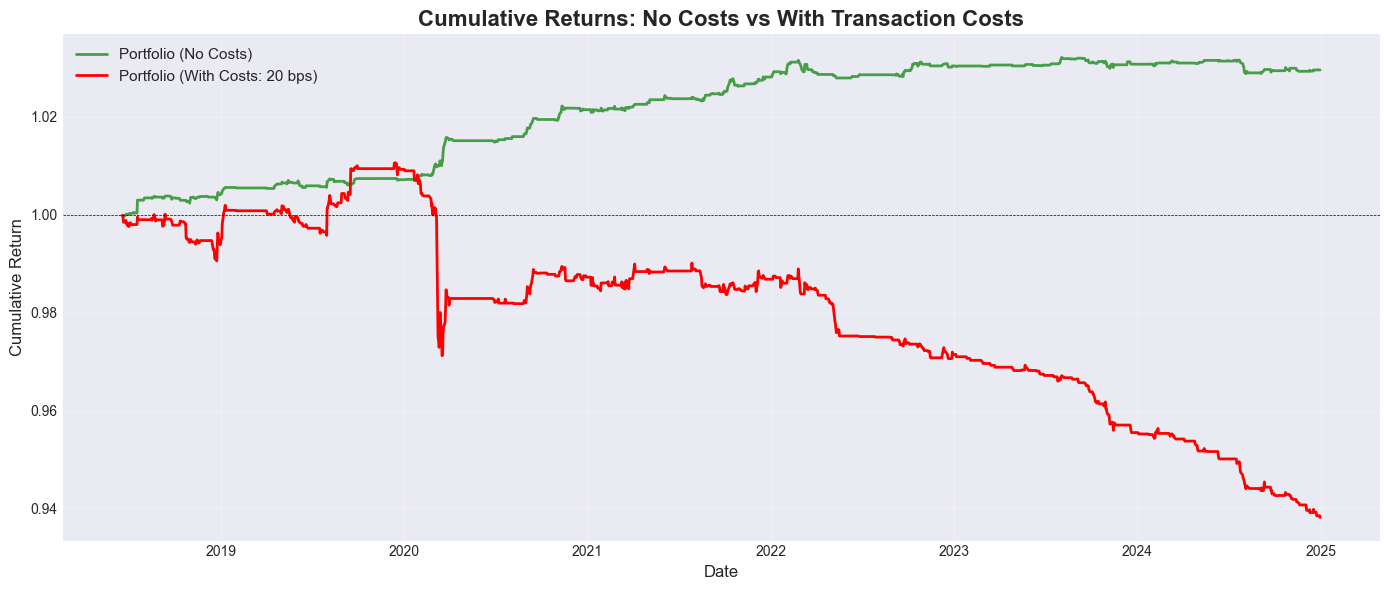

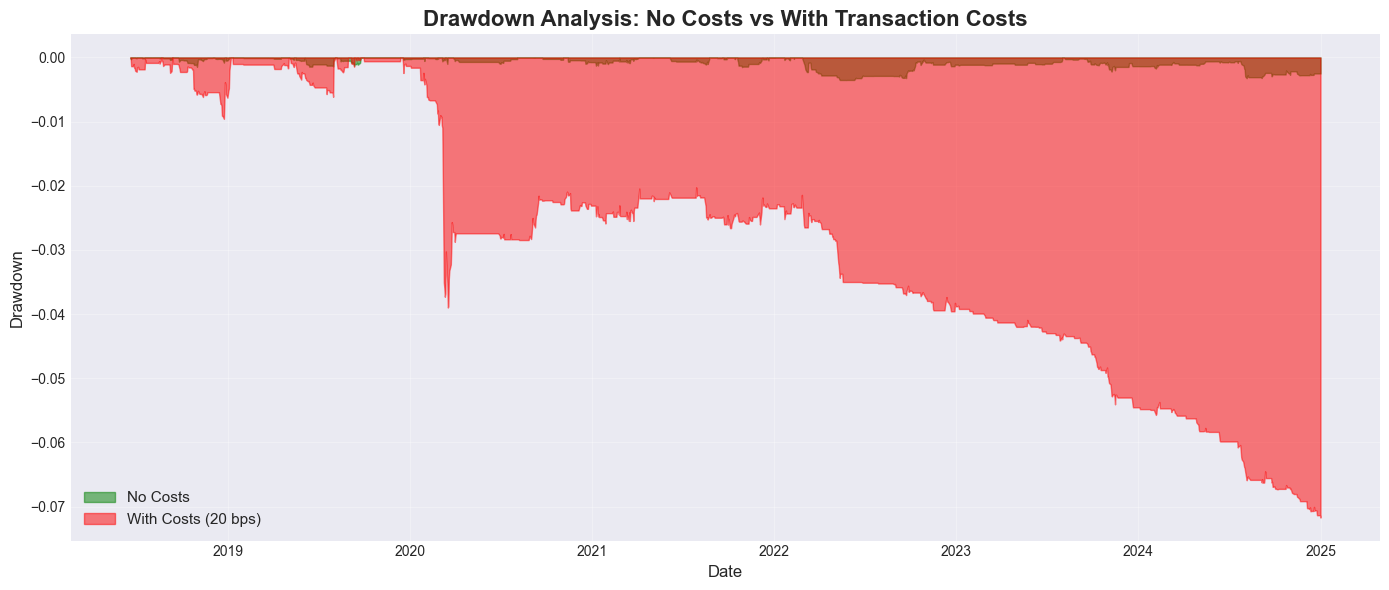

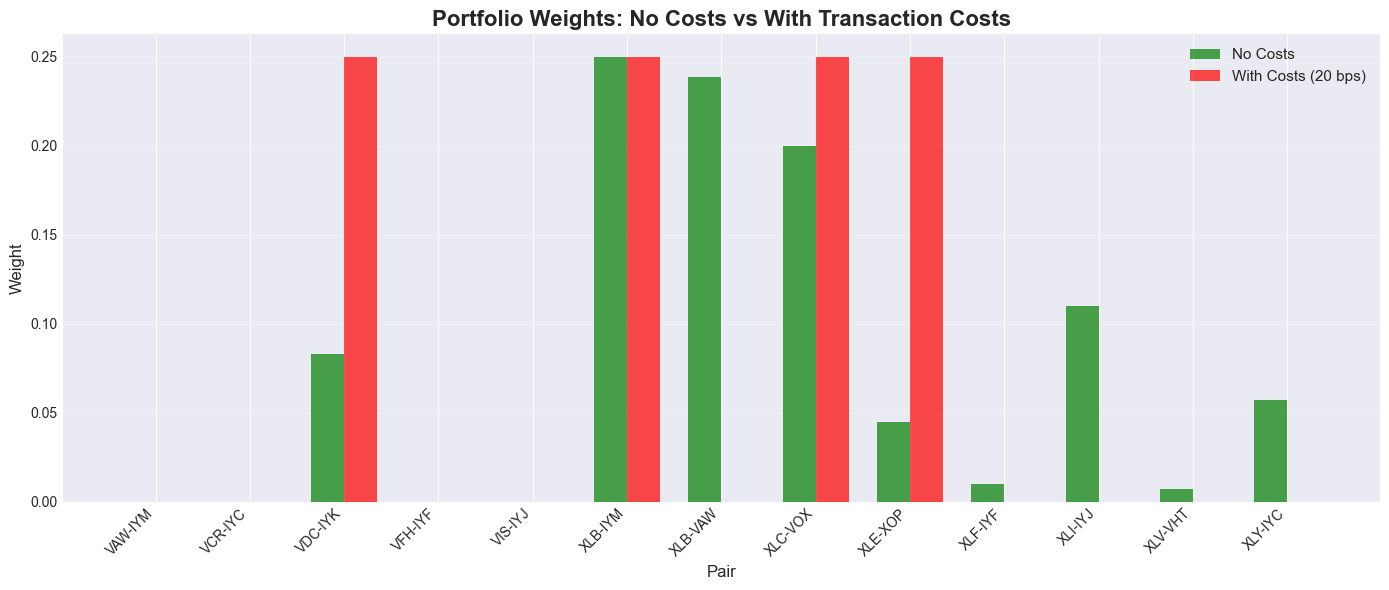

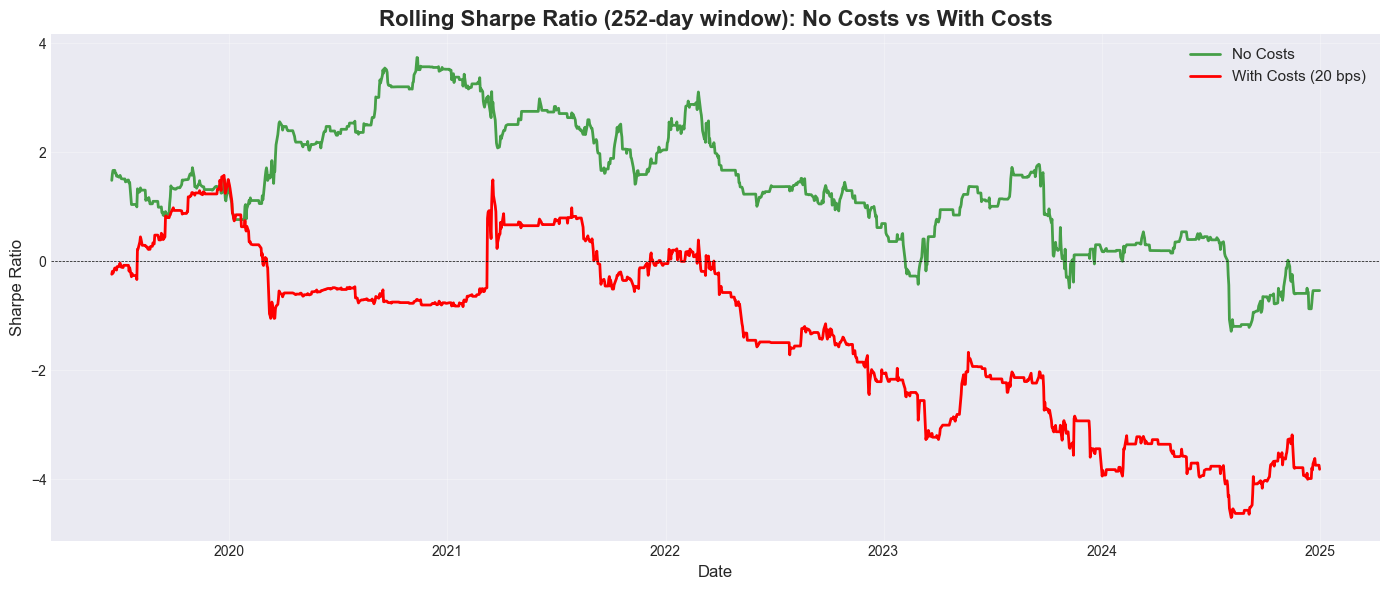

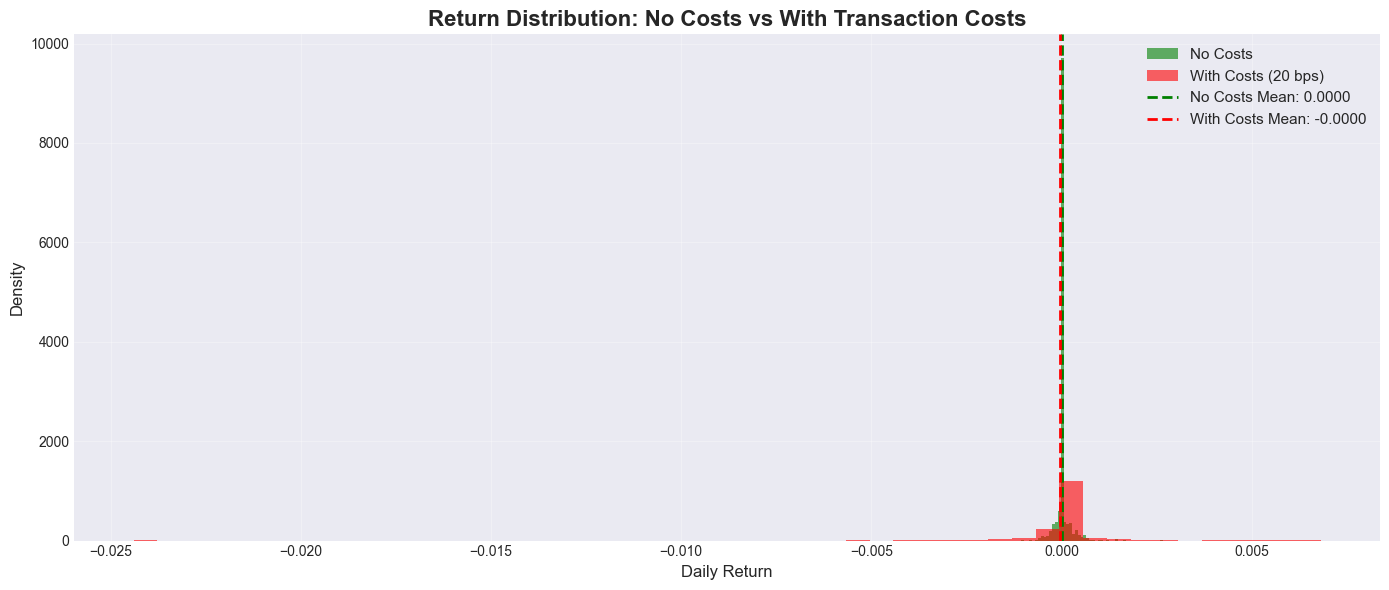

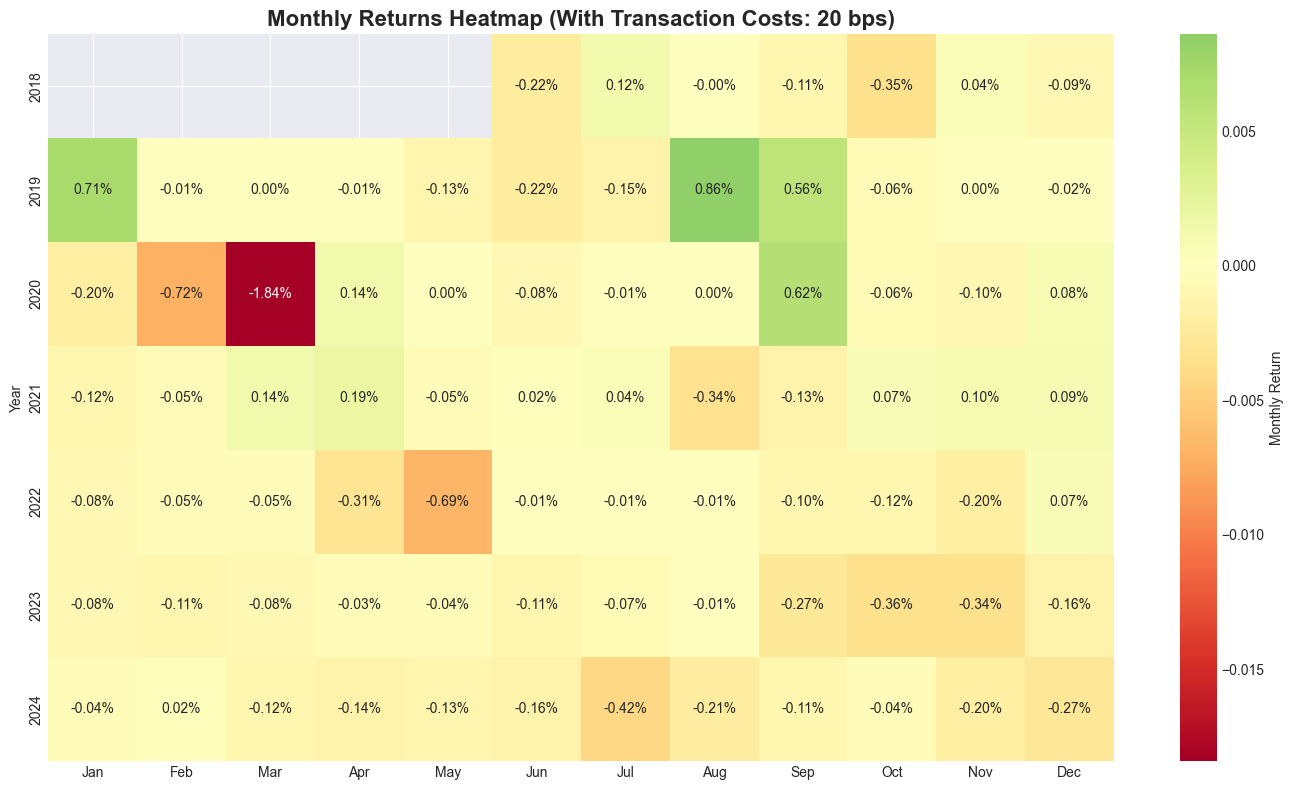

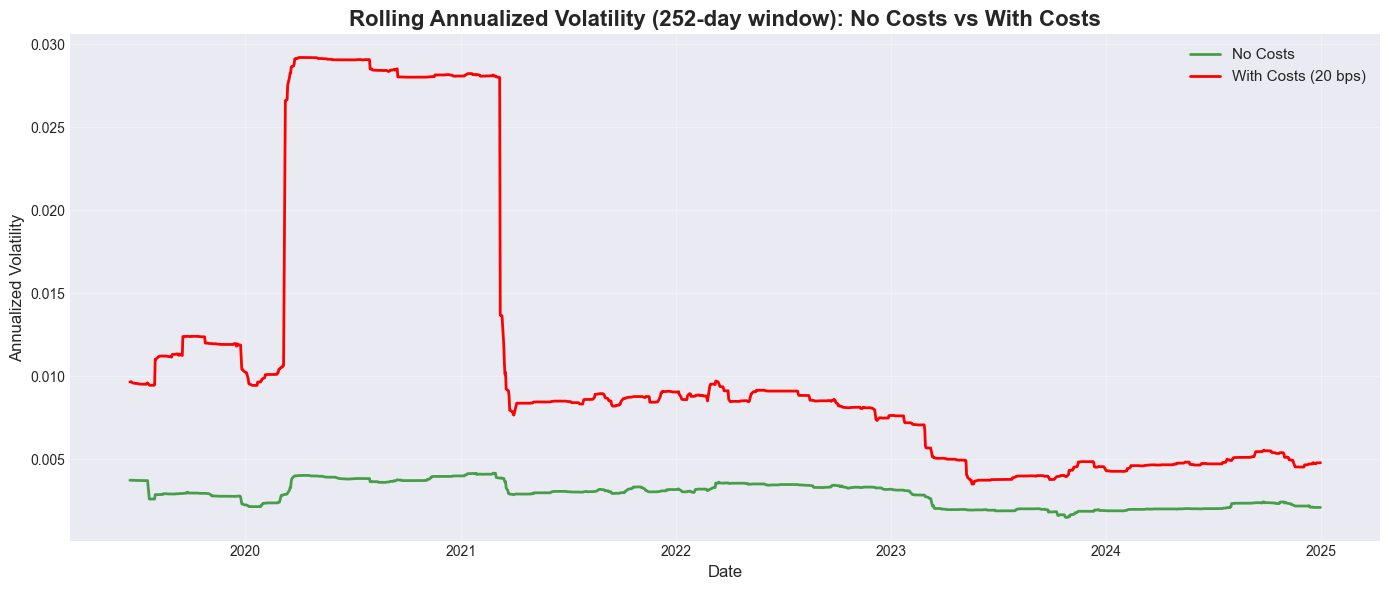

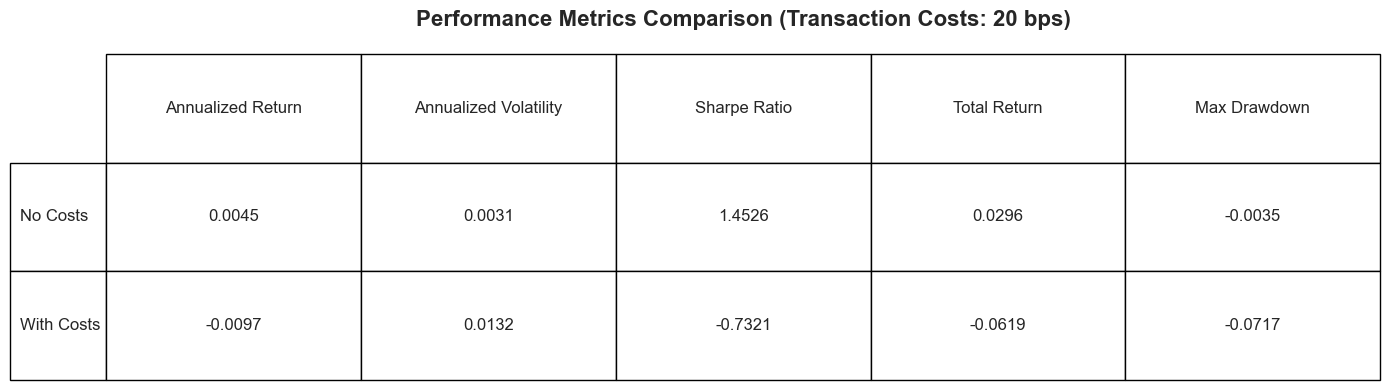


✓ All visualizations with transaction costs generated!


In [48]:
# Comprehensive Visualizations with Transaction Costs
print("="*70)
print("Generating Visualizations with Transaction Costs")
print("="*70)

# Extract data
opt_returns_costs = portfolio_returns_with_costs
opt_weights_costs = optimal_weights_with_costs
opt_metrics_costs = portfolio_metrics_with_costs

# Original portfolio (no costs) for comparison
orig_returns = portfolio_returns
orig_weights = optimal_weights
orig_metrics = portfolio_metrics

window = 252

# 1. Cumulative Returns Comparison (No Costs vs With Costs)
plt.figure(figsize=(14, 6))
cum_ret_no_costs = (1 + orig_returns).cumprod()
cum_ret_with_costs = (1 + opt_returns_costs).cumprod()
plt.plot(cum_ret_no_costs.index, cum_ret_no_costs.values, 
         label='Portfolio (No Costs)', linewidth=2, alpha=0.7, color='green')
plt.plot(cum_ret_with_costs.index, cum_ret_with_costs.values, 
         label=f'Portfolio (With Costs: {TOTAL_COST_BPS} bps)', linewidth=2, color='red')
plt.title('Cumulative Returns: No Costs vs With Transaction Costs', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 2. Drawdown Analysis Comparison
plt.figure(figsize=(14, 6))
equity_no_costs = (1 + orig_returns).cumprod()
equity_with_costs = (1 + opt_returns_costs).cumprod()
running_max_no_costs = equity_no_costs.expanding().max()
running_max_with_costs = equity_with_costs.expanding().max()
dd_no_costs = (equity_no_costs - running_max_no_costs) / running_max_no_costs
dd_with_costs = (equity_with_costs - running_max_with_costs) / running_max_with_costs

# Ensure numeric values and proper index handling
dd_no_costs_clean = dd_no_costs.dropna()
dd_with_costs_clean = dd_with_costs.dropna()

plt.fill_between(dd_no_costs_clean.index, dd_no_costs_clean.values.astype(float), 0, alpha=0.5, 
                 label='No Costs', color='green')
plt.fill_between(dd_with_costs_clean.index, dd_with_costs_clean.values.astype(float), 0, alpha=0.5, 
                 label=f'With Costs ({TOTAL_COST_BPS} bps)', color='red')
plt.title('Drawdown Analysis: No Costs vs With Transaction Costs', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Drawdown', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Portfolio Weights Comparison
plt.figure(figsize=(14, 6))
pairs = sorted(set(list(orig_weights.keys()) + list(opt_weights_costs.keys())))
no_costs_vals = [orig_weights.get(p, 0) for p in pairs]
with_costs_vals = [opt_weights_costs.get(p, 0) for p in pairs]
x = np.arange(len(pairs))
width = 0.35
plt.bar(x - width/2, no_costs_vals, width, label='No Costs', alpha=0.7, color='green')
plt.bar(x + width/2, with_costs_vals, width, label=f'With Costs ({TOTAL_COST_BPS} bps)', alpha=0.7, color='red')
plt.title('Portfolio Weights: No Costs vs With Transaction Costs', fontsize=16, fontweight='bold')
plt.xlabel('Pair', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.xticks(x, pairs, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# 4. Rolling Sharpe Ratio Comparison
plt.figure(figsize=(14, 6))
rolling_sharpe_no_costs = orig_returns.rolling(window=window).apply(
    lambda x: x.mean() * 252 / (x.std() * np.sqrt(252)) if x.std() > 0 else 0
)
rolling_sharpe_with_costs = opt_returns_costs.rolling(window=window).apply(
    lambda x: x.mean() * 252 / (x.std() * np.sqrt(252)) if x.std() > 0 else 0
)
plt.plot(rolling_sharpe_no_costs.index, rolling_sharpe_no_costs.values, 
         label='No Costs', alpha=0.7, linewidth=2, color='green')
plt.plot(rolling_sharpe_with_costs.index, rolling_sharpe_with_costs.values, 
         label=f'With Costs ({TOTAL_COST_BPS} bps)', linewidth=2, color='red')
plt.title(f'Rolling Sharpe Ratio ({window}-day window): No Costs vs With Costs', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 5. Return Distribution Comparison
plt.figure(figsize=(14, 6))
plt.hist(orig_returns.dropna(), bins=50, alpha=0.6, label='No Costs', 
         density=True, color='green')
plt.hist(opt_returns_costs.dropna(), bins=50, alpha=0.6, label=f'With Costs ({TOTAL_COST_BPS} bps)', 
         density=True, color='red')
plt.axvline(orig_returns.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'No Costs Mean: {orig_returns.mean():.4f}')
plt.axvline(opt_returns_costs.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'With Costs Mean: {opt_returns_costs.mean():.4f}')
plt.title('Return Distribution: No Costs vs With Transaction Costs', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Monthly Returns Heatmap (With Costs)
plt.figure(figsize=(14, 8))
opt_monthly_costs = opt_returns_costs.resample('M').apply(lambda x: (1 + x).prod() - 1)
opt_monthly_df_costs = pd.DataFrame({
    'Year': opt_monthly_costs.index.year,
    'Month': opt_monthly_costs.index.month,
    'Return': opt_monthly_costs.values
}).pivot(index='Year', columns='Month', values='Return')
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
opt_monthly_df_costs.columns = [month_names.get(col, col) for col in opt_monthly_df_costs.columns]
sns.heatmap(opt_monthly_df_costs, annot=True, fmt='.2%', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Monthly Return'}, xticklabels=True, yticklabels=True)
plt.title(f'Monthly Returns Heatmap (With Transaction Costs: {TOTAL_COST_BPS} bps)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Rolling Volatility Comparison
plt.figure(figsize=(14, 6))
rolling_vol_no_costs = orig_returns.rolling(window=window).std() * np.sqrt(252)
rolling_vol_with_costs = opt_returns_costs.rolling(window=window).std() * np.sqrt(252)
plt.plot(rolling_vol_no_costs.index, rolling_vol_no_costs.values, 
         label='No Costs', alpha=0.7, linewidth=2, color='green')
plt.plot(rolling_vol_with_costs.index, rolling_vol_with_costs.values, 
         label=f'With Costs ({TOTAL_COST_BPS} bps)', linewidth=2, color='red')
plt.title(f'Rolling Annualized Volatility ({window}-day window): No Costs vs With Costs', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Annualized Volatility', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Performance Metrics Comparison Table
plt.figure(figsize=(14, 4))
plt.axis('off')
metrics_comparison_costs = pd.DataFrame({
    'No Costs': orig_metrics,
    'With Costs': opt_metrics_costs
}).T
display_metrics_costs = {}
for metric in ['annualized_return', 'annualized_volatility', 'sharpe_ratio', 
               'total_return', 'max_drawdown']:
    if metric in metrics_comparison_costs.columns:
        display_metrics_costs[metric.replace('_', ' ').title()] = metrics_comparison_costs[metric]

display_df_costs = pd.DataFrame(display_metrics_costs)
table = plt.table(cellText=[[f"{val:.4f}" if isinstance(val, float) else str(val) 
                              for val in row] for row in display_df_costs.values],
                  rowLabels=display_df_costs.index,
                  colLabels=display_df_costs.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.5)
plt.title(f'Performance Metrics Comparison (Transaction Costs: {TOTAL_COST_BPS} bps)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ All visualizations with transaction costs generated!")


Transaction Cost Sensitivity Analysis


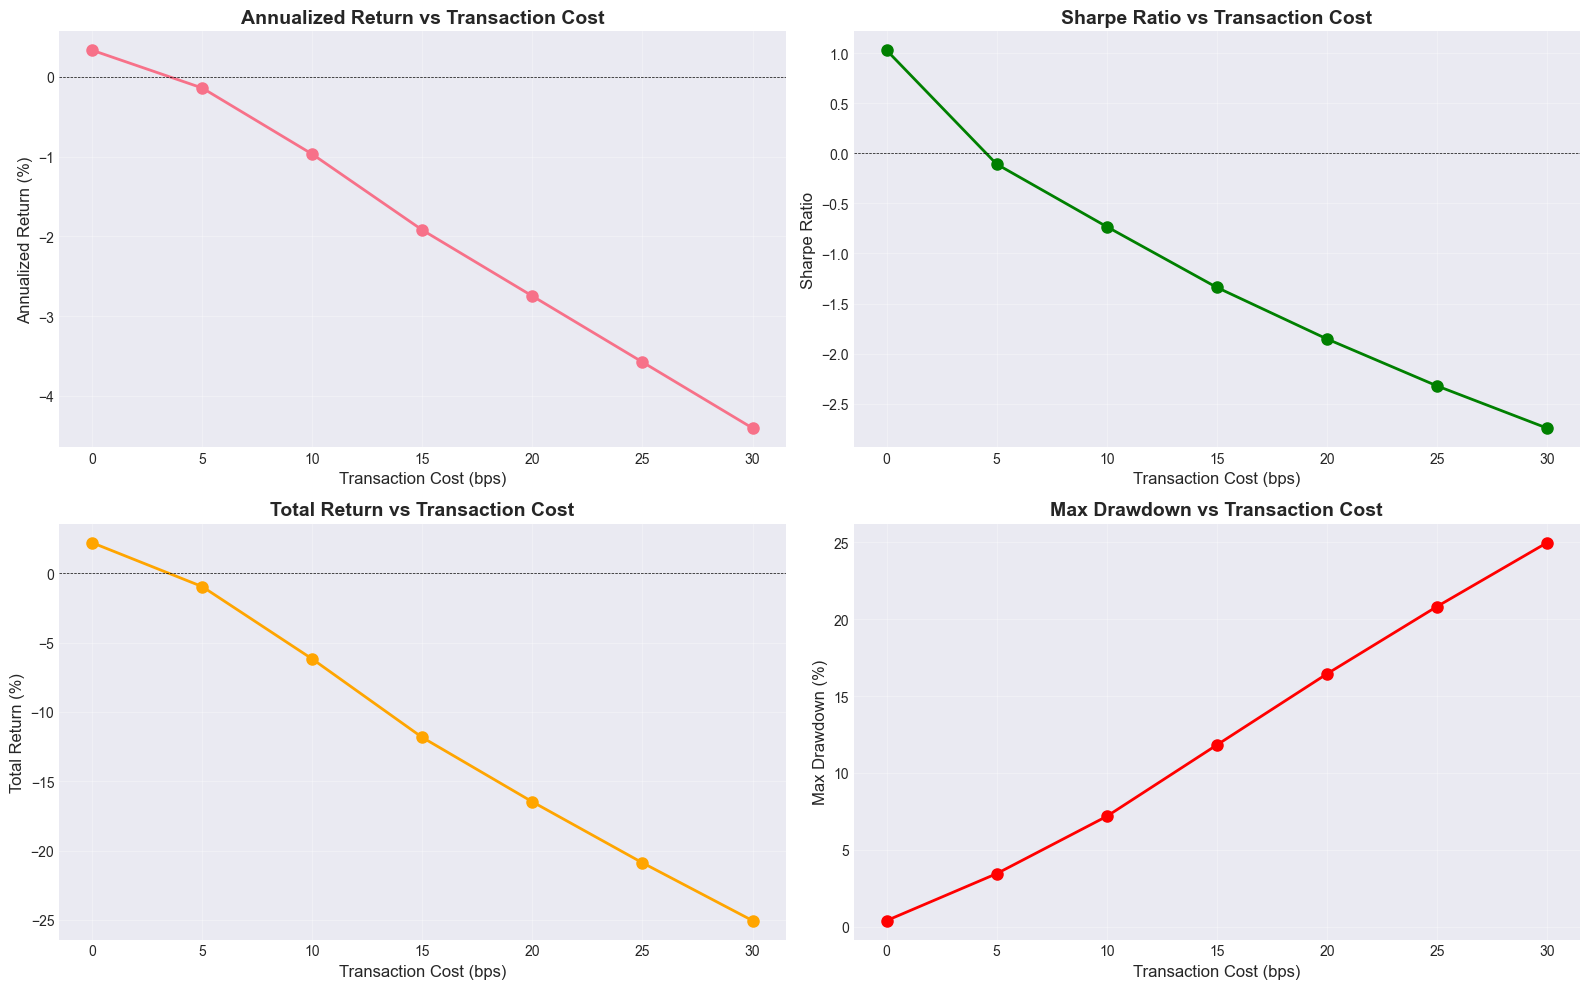


Sensitivity Analysis Results:
----------------------------------------------------------------------


,Cost (bps),Annualized Return,Sharpe Ratio,Total Return,Max Drawdown
0,0,0.0033,1.0299,0.0219,-0.0039
1,5,-0.0014,-0.1078,-0.0097,-0.0344
2,10,-0.0097,-0.7321,-0.0619,-0.0717
3,15,-0.0192,-1.3388,-0.1185,-0.1181
4,20,-0.0275,-1.8534,-0.1649,-0.1644
5,25,-0.0358,-2.3223,-0.2088,-0.2082
6,30,-0.0440,-2.7444,-0.2505,-0.2498



💡 Break-even Analysis:
   - Strategy remains profitable (positive return) up to ~0 bps
   - Strategy remains attractive (positive Sharpe) up to ~0 bps
   - Current setting: 20 bps


In [49]:
# Sensitivity Analysis: Test Different Transaction Cost Levels
print("="*70)
print("Transaction Cost Sensitivity Analysis")
print("="*70)

# Test different cost levels
cost_levels = [0, 5, 10, 15, 20, 25, 30]  # in basis points
sensitivity_results = []

for cost_bps in cost_levels:
    # Recompute returns with this cost level
    temp_pair_returns = {}
    for pair_name, results in pair_results.items():
        signals = results['signals']
        pair_data = results['pair_data']
        temp_returns = compute_strategy_returns_with_costs(
            signals, pair_data,
            transaction_cost_bps=cost_bps,
            spread_cost_bps=cost_bps/2  # Assume spread is half of transaction cost
        )
        temp_pair_returns[pair_name] = temp_returns
    
    # Optimize portfolio
    temp_opt = optimize_portfolio_weights(
        temp_pair_returns,
        objective='sharpe',
        constraints=weight_constraints,
        method='SLSQP'
    )
    
    temp_metrics = temp_opt['metrics']
    
    sensitivity_results.append({
        'Cost (bps)': cost_bps,
        'Annualized Return': temp_metrics.get('annualized_return', 0),
        'Sharpe Ratio': temp_metrics.get('sharpe_ratio', 0),
        'Total Return': temp_metrics.get('total_return', 0),
        'Max Drawdown': temp_metrics.get('max_drawdown', 0)
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

# Plot sensitivity
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(sensitivity_df['Cost (bps)'], sensitivity_df['Annualized Return'] * 100, 
                marker='o', linewidth=2, markersize=8)
axes[0, 0].set_title('Annualized Return vs Transaction Cost', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Transaction Cost (bps)', fontsize=12)
axes[0, 0].set_ylabel('Annualized Return (%)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[0, 1].plot(sensitivity_df['Cost (bps)'], sensitivity_df['Sharpe Ratio'], 
                marker='o', linewidth=2, markersize=8, color='green')
axes[0, 1].set_title('Sharpe Ratio vs Transaction Cost', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Transaction Cost (bps)', fontsize=12)
axes[0, 1].set_ylabel('Sharpe Ratio', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[1, 0].plot(sensitivity_df['Cost (bps)'], sensitivity_df['Total Return'] * 100, 
                marker='o', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_title('Total Return vs Transaction Cost', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Transaction Cost (bps)', fontsize=12)
axes[1, 0].set_ylabel('Total Return (%)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[1, 1].plot(sensitivity_df['Cost (bps)'], abs(sensitivity_df['Max Drawdown']) * 100, 
                marker='o', linewidth=2, markersize=8, color='red')
axes[1, 1].set_title('Max Drawdown vs Transaction Cost', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Cost (bps)', fontsize=12)
axes[1, 1].set_ylabel('Max Drawdown (%)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSensitivity Analysis Results:")
print("-"*70)
display(sensitivity_df.style.format({
    'Cost (bps)': '{:.0f}',
    'Annualized Return': '{:.4f}',
    'Sharpe Ratio': '{:.4f}',
    'Total Return': '{:.4f}',
    'Max Drawdown': '{:.4f}'
}))

# Find break-even cost (where Sharpe becomes negative or return becomes zero)
break_even_sharpe = sensitivity_df[sensitivity_df['Sharpe Ratio'] > 0]['Cost (bps)'].max()
break_even_return = sensitivity_df[sensitivity_df['Annualized Return'] > 0]['Cost (bps)'].max()

print(f"\n💡 Break-even Analysis:")
print(f"   - Strategy remains profitable (positive return) up to ~{break_even_return:.0f} bps")
print(f"   - Strategy remains attractive (positive Sharpe) up to ~{break_even_sharpe:.0f} bps")
print(f"   - Current setting: {TOTAL_COST_BPS} bps")


## 9. End-to-End Optimization with Transaction Costs {#end_to_end_optimization}

**Key Innovation:** Optimize Kalman filter parameters AND portfolio weights while INCLUDING transaction costs in the optimization objective. This ensures we find parameters that work in realistic trading conditions.

### Approach:
1. Optimize Kalman filter parameters for each pair using returns that INCLUDE transaction costs
2. Optimize portfolio weights using those cost-adjusted returns
3. Compare with previous optimizations (without costs in objective)


In [50]:
# End-to-End Optimization: Kalman Parameters + Portfolio Weights WITH Transaction Costs

print("="*70)
print("End-to-End Optimization with Transaction Costs")
print("="*70)
print("\nThis optimization:")
print("  1. Optimizes Kalman filter parameters using returns WITH transaction costs")
print("  2. Optimizes portfolio weights using those cost-adjusted returns")
print("  3. Ensures parameters work in realistic trading conditions")
print(f"\nTransaction costs: {TRANSACTION_COST_BPS} bps transaction + {SPREAD_COST_BPS} bps spread per side = {TOTAL_COST_BPS} bps round-trip\n")

# Step 1: Optimize Kalman filter parameters WITH transaction costs for each pair
print("="*70)
print("Step 1: Optimizing Kalman Filter Parameters WITH Transaction Costs")
print("="*70)

optimized_hedge_results_with_costs = {}

for pair_name, pair_data in pair_data_dict.items():
    print(f"\nOptimizing {pair_name} with transaction costs...")
    
    try:
        # Set parameter bounds for optimization
        param_bounds = {
            'observation_noise': (0.0001, 0.01),
            'state_noise': (0.00001, 0.001),
            'initial_beta': (0.5, 1.5)
        }
        
        # Optimize WITH transaction costs
        hedge_opt_result = optimize_hedge_ratios(
            pair_data,
            kalman_config=config.KALMAN_CONFIG,
            objective='sharpe',
            param_bounds=param_bounds,
            method='fast',
            use_subset=True,
            subset_size=1000,
            transaction_cost_bps=TRANSACTION_COST_BPS,
            spread_cost_bps=SPREAD_COST_BPS
        )
        
        optimized_hedge_results_with_costs[pair_name] = hedge_opt_result
        
        # Display results
        opt_config = hedge_opt_result['optimal_config']
        metrics = hedge_opt_result['metrics']
        
        print(f"  Optimal parameters:")
        print(f"    observation_noise: {opt_config['observation_noise']:.6f}")
        print(f"    state_noise: {opt_config['state_noise']:.6f}")
        print(f"    initial_beta: {opt_config['initial_beta']:.4f}")
        print(f"  Performance (WITH costs): Sharpe={metrics['sharpe_ratio']:.3f}, "
              f"AnnRet={metrics['annualized_return']:.2%}")
        
    except Exception as e:
        print(f"  ✗ Error optimizing {pair_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n✓ Optimized Kalman parameters WITH costs for {len(optimized_hedge_results_with_costs)} pairs")


End-to-End Optimization with Transaction Costs

This optimization:
  1. Optimizes Kalman filter parameters using returns WITH transaction costs
  2. Optimizes portfolio weights using those cost-adjusted returns
  3. Ensures parameters work in realistic trading conditions

Transaction costs: 10 bps transaction + 5 bps spread per side = 20 bps round-trip

Step 1: Optimizing Kalman Filter Parameters WITH Transaction Costs

Optimizing XLRE-IYR with transaction costs...
  ✗ Error optimizing XLRE-IYR: setting an array element with a sequence.

Optimizing XLRE-VNQ with transaction costs...


TypeError: float() argument must be a string or a real number, not 'NAType'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/tt/cvw7nz6j26z97xt52x5sh3m80000gn/T/ipykernel_28009/1861797106.py", line 31, in <module>
    hedge_opt_result = optimize_hedge_ratios(
        pair_data,
    ...<7 lines>...
        spread_cost_bps=SPREAD_COST_BPS
    )
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/portfolio_optimization.py", line 320, in optimize_hedge_ratios
    kalman_result = estimate_hedge_ratio_kalman(pair_data, optimal_config)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 278, in estimate_hedge_ratio_kalman
    result = kf.smooth(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 185, in smooth
    filter_result = sel

  ✗ Error optimizing XLRE-VNQ: setting an array element with a sequence.

Optimizing XLB-VAW with transaction costs...


TypeError: float() argument must be a string or a real number, not 'NAType'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/tt/cvw7nz6j26z97xt52x5sh3m80000gn/T/ipykernel_28009/1861797106.py", line 31, in <module>
    hedge_opt_result = optimize_hedge_ratios(
        pair_data,
    ...<7 lines>...
        spread_cost_bps=SPREAD_COST_BPS
    )
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/portfolio_optimization.py", line 320, in optimize_hedge_ratios
    kalman_result = estimate_hedge_ratio_kalman(pair_data, optimal_config)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 278, in estimate_hedge_ratio_kalman
    result = kf.smooth(y, x)
  File "/Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project/src/kalman_filter.py", line 185, in smooth
    filter_result = sel

  Optimal parameters:
    observation_noise: 0.007525
    state_noise: 0.000258
    initial_beta: 0.5000
  Performance (WITH costs): Sharpe=-1.906, AnnRet=-1.36%

Optimizing XLC-VOX with transaction costs...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.000014
    initial_beta: 0.7500
  Performance (WITH costs): Sharpe=-1.027, AnnRet=-0.81%

Optimizing XLV-VHT with transaction costs...
  Optimal parameters:
    observation_noise: 0.007525
    state_noise: 0.000010
    initial_beta: 0.7500
  Performance (WITH costs): Sharpe=-1.472, AnnRet=-1.02%

Optimizing VAW-IYM with transaction costs...
  Optimal parameters:
    observation_noise: 0.002575
    state_noise: 0.000010
    initial_beta: 0.5000
  Performance (WITH costs): Sharpe=-1.425, AnnRet=-1.23%

Optimizing VFH-IYF with transaction costs...
  Optimal parameters:
    observation_noise: 0.007525
    state_noise: 0.000010
    initial_beta: 0.5000
  Performance (WITH costs): Sharpe=-1.453, AnnRet=-1.35%

Optim

In [51]:
# Step 2: Extract strategy returns (already include transaction costs) and optimize portfolio weights
print("\n" + "="*70)
print("Step 2: Optimizing Portfolio Weights with Cost-Adjusted Returns")
print("="*70)

# Extract strategy returns (these already include transaction costs)
optimized_pair_returns_with_costs = {
    pair_name: result['strategy_returns'] 
    for pair_name, result in optimized_hedge_results_with_costs.items()
}

# Optimize portfolio weights using returns that already include costs
print("\nOptimizing portfolio weights...")
opt_result_end_to_end = optimize_portfolio_weights(
    optimized_pair_returns_with_costs,
    objective='sharpe',
    constraints=weight_constraints,
    method='SLSQP'
)

optimal_weights_end_to_end = opt_result_end_to_end['weights']
portfolio_returns_end_to_end = opt_result_end_to_end['portfolio_returns']
portfolio_metrics_end_to_end = opt_result_end_to_end['metrics']

print("\nOptimal Portfolio Weights (End-to-End Optimization with Costs):")
print("-"*70)
for pair_name, weight in sorted(optimal_weights_end_to_end.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {pair_name:12s}: {weight:8.4f} ({weight*100:6.2f}%)")

print("\nPortfolio Performance Metrics (End-to-End Optimization with Costs):")
print("-"*70)
for metric, value in portfolio_metrics_end_to_end.items():
    if isinstance(value, float):
        if 'return' in metric.lower() or 'sharpe' in metric.lower():
            print(f"  {metric:25s}: {value:10.4f} ({value*100:.2f}%)")
        else:
            print(f"  {metric:25s}: {value:10.4f}")
    else:
        print(f"  {metric:25s}: {value}")

# Store results
end_to_end_results = {
    'optimized_hedge_results': optimized_hedge_results_with_costs,
    'optimal_weights': optimal_weights_end_to_end,
    'portfolio_returns': portfolio_returns_end_to_end,
    'portfolio_metrics': portfolio_metrics_end_to_end
}



Step 2: Optimizing Portfolio Weights with Cost-Adjusted Returns

Optimizing portfolio weights...

Optimal Portfolio Weights (End-to-End Optimization with Costs):
----------------------------------------------------------------------
  XLC-VOX     :   0.2500 ( 25.00%)
  XLV-VHT     :   0.2500 ( 25.00%)
  XLE-XOP     :   0.2500 ( 25.00%)
  XLY-IYC     :   0.2500 ( 25.00%)
  VDC-IYK     :   0.0000 (  0.00%)
  VCR-IYC     :   0.0000 (  0.00%)
  XLI-IYJ     :   0.0000 (  0.00%)
  XLB-IYM     :   0.0000 (  0.00%)
  VFH-IYF     :   0.0000 (  0.00%)
  XLB-VAW     :   0.0000 (  0.00%)
  VAW-IYM     :   0.0000 (  0.00%)
  VIS-IYJ     :   0.0000 (  0.00%)
  XLF-IYF     :   0.0000 (  0.00%)

Portfolio Performance Metrics (End-to-End Optimization with Costs):
----------------------------------------------------------------------
  annualized_return        :    -0.0087 (-0.87%)
  annualized_volatility    :     0.0140
  sharpe_ratio             :    -0.6245 (-62.45%)
  total_return             :    

In [52]:
# Step 3: Compare all optimization approaches
print("\n" + "="*70)
print("Step 3: Comparison of All Optimization Approaches")
print("="*70)

comparison_data = []

# 1. Original (no optimization, no costs)
if 'portfolio_metrics' in locals():
    comparison_data.append({
        'Approach': 'Original (No Opt, No Costs)',
        'Annualized Return': portfolio_metrics.get('annualized_return', 0),
        'Sharpe Ratio': portfolio_metrics.get('sharpe_ratio', 0),
        'Total Return': portfolio_metrics.get('total_return', 0),
        'Max Drawdown': portfolio_metrics.get('max_drawdown', 0)
    })

# 2. Optimized hedge ratios (no costs in optimization)
if 'portfolio_metrics_optimized' in locals():
    comparison_data.append({
        'Approach': 'Optimized Hedge (No Costs in Obj)',
        'Annualized Return': portfolio_metrics_optimized.get('annualized_return', 0),
        'Sharpe Ratio': portfolio_metrics_optimized.get('sharpe_ratio', 0),
        'Total Return': portfolio_metrics_optimized.get('total_return', 0),
        'Max Drawdown': portfolio_metrics_optimized.get('max_drawdown', 0)
    })

# 3. Portfolio with costs (optimized without costs, then costs added)
if 'portfolio_metrics_with_costs' in locals():
    comparison_data.append({
        'Approach': 'Optimized Then Add Costs',
        'Annualized Return': portfolio_metrics_with_costs.get('annualized_return', 0),
        'Sharpe Ratio': portfolio_metrics_with_costs.get('sharpe_ratio', 0),
        'Total Return': portfolio_metrics_with_costs.get('total_return', 0),
        'Max Drawdown': portfolio_metrics_with_costs.get('max_drawdown', 0)
    })

# 4. End-to-end optimization (costs in objective)
comparison_data.append({
    'Approach': 'End-to-End (Costs in Obj)',
    'Annualized Return': portfolio_metrics_end_to_end.get('annualized_return', 0),
    'Sharpe Ratio': portfolio_metrics_end_to_end.get('sharpe_ratio', 0),
    'Total Return': portfolio_metrics_end_to_end.get('total_return', 0),
    'Max Drawdown': portfolio_metrics_end_to_end.get('max_drawdown', 0)
})

comparison_df = pd.DataFrame(comparison_data)

print("\nPerformance Comparison:")
print("-"*70)
display(comparison_df.style.format({
    'Annualized Return': '{:.4f}',
    'Sharpe Ratio': '{:.4f}',
    'Total Return': '{:.4f}',
    'Max Drawdown': '{:.4f}'
}))

# Key insights
print("\n" + "="*70)
print("Key Insights:")
print("="*70)
print("1. End-to-end optimization accounts for transaction costs during parameter selection")
print("2. This may find different Kalman parameters that reduce trading frequency")
print("3. Portfolio weights are optimized using realistic, cost-adjusted returns")
print("4. This approach is more realistic for actual trading implementation")



Step 3: Comparison of All Optimization Approaches

Performance Comparison:
----------------------------------------------------------------------


,Approach,Annualized Return,Sharpe Ratio,Total Return,Max Drawdown
0,"Original (No Opt, No Costs)",0.0045,1.4526,0.0296,-0.0035
1,Optimized Hedge (No Costs in Obj),0.0059,2.3434,0.0390,-0.0019
2,Optimized Then Add Costs,-0.0097,-0.7321,-0.0619,-0.0717
3,End-to-End (Costs in Obj),-0.0087,-0.6245,-0.0561,-0.0576



Key Insights:
1. End-to-end optimization accounts for transaction costs during parameter selection
2. This may find different Kalman parameters that reduce trading frequency
3. Portfolio weights are optimized using realistic, cost-adjusted returns
4. This approach is more realistic for actual trading implementation


In [56]:
# Sensitivity Analysis: Transaction Cost Levels
print("="*70)
print("Sensitivity Analysis: Transaction Cost Levels")
print("="*70)

# Define transaction cost levels to test (in basis points)
cost_levels = [0, 10, 20, 50]

# Store results for each cost level
sensitivity_results = []

# For 0 bps, use the already-optimized results (if available)
if cost_levels[0] == 0:
    if 'portfolio_returns_optimized' in locals() and 'portfolio_metrics_optimized' in locals():
        print("\nUsing pre-computed optimized results for 0 bps (optimized hedge ratios, no costs)")
        print(f"  Annualized Return: {portfolio_metrics_optimized.get('annualized_return', 0)*100:.2f}%")
        print(f"  Sharpe Ratio: {portfolio_metrics_optimized.get('sharpe_ratio', 0):.4f}")
        
        # Estimate turnover for 0 bps case
        if len(portfolio_returns_optimized) > 0:
            turnover_estimate = portfolio_returns_optimized.std() * np.sqrt(252) * 2
        else:
            turnover_estimate = 0
        
        sensitivity_results.append({
            'Cost Level': '0 bps',
            'Ann. Return': portfolio_metrics_optimized.get('annualized_return', 0) * 100,
            'Sharpe': portfolio_metrics_optimized.get('sharpe_ratio', 0),
            'Max DD': portfolio_metrics_optimized.get('max_drawdown', 0) * 100,
            'Turnover': turnover_estimate
        })
        print(f"  Added 0 bps result to sensitivity analysis\n")
        cost_levels_to_process = cost_levels[1:]  # Skip 0 bps, already done
    else:
        print("\nNote: Optimized results not found. Will recompute 0 bps from scratch.")
        cost_levels_to_process = cost_levels
else:
    cost_levels_to_process = cost_levels

# Check if we have pair data for other cost levels
if 'pair_data_dict' not in locals():
    print("\nError: pair_data_dict not found. Using pair_returns_dict if available...")
    if 'pair_returns_dict' not in locals():
        print("Error: No pair data available. Please run previous cells first.")
        cost_levels_to_process = []
    else:
        print("Using pair_returns_dict (gross returns)")
        use_gross_returns = True
        pairs_to_use = pair_returns_dict
else:
    print("Using pair_data_dict (will compute returns with costs)")
    use_gross_returns = False
    pairs_to_use = pair_data_dict

if 'pairs_to_use' in locals() and len(cost_levels_to_process) > 0:
    print(f"\nAnalyzing {len(pairs_to_use)} pairs across {len(cost_levels_to_process)} additional cost levels...\n")
    
    for cost_bps in cost_levels_to_process:
        print(f"Processing {cost_bps} bps...", end=" ")
        
        try:
            if use_gross_returns:
                # Apply costs to gross returns (simplified approach)
                # For accurate costs, we'd need to recompute with actual trades
                cost_adjusted_returns = {}
                for pair_name, gross_returns in pairs_to_use.items():
                    if cost_bps > 0:
                        # Estimate costs based on return volatility and frequency
                        # This is an approximation
                        cost_per_trade = cost_bps / 10000  # Convert to decimal
                        # Rough estimate: assume trading frequency proportional to volatility
                        estimated_trades_per_year = gross_returns.abs().sum() * 252 / len(gross_returns)
                        annual_cost = cost_per_trade * estimated_trades_per_year
                        daily_cost = annual_cost / 252
                        net_returns = gross_returns - daily_cost
                        cost_adjusted_returns[pair_name] = net_returns
                    else:
                        cost_adjusted_returns[pair_name] = gross_returns
            else:
                # Recompute returns with actual costs for each pair
                from src.kalman_filter import estimate_hedge_ratio_kalman
                from src.signal_generation import generate_signals, compute_position_sizes
                from src.portfolio_optimization import _compute_strategy_returns_with_costs, _compute_strategy_returns_simple
                import config
                
                cost_adjusted_returns = {}
                for pair_name, pair_df in pairs_to_use.items():
                    try:
                        # Run Kalman filter
                        kalman_result = estimate_hedge_ratio_kalman(pair_df, config.KALMAN_CONFIG)
                        spread = kalman_result['spread']
                        
                        # Generate signals
                        signals = generate_signals(pair_df, spread, config.SIGNAL_CONFIG)
                        signals = compute_position_sizes(signals, pair_df, config.BACKTEST_CONFIG)
                        
                        # Compute returns with costs
                        if cost_bps > 0:
                            trans_cost = cost_bps / 2  # Half for each side
                            spread_cost = 5  # Fixed spread cost
                            strategy_returns = _compute_strategy_returns_with_costs(
                                signals, pair_df, trans_cost, spread_cost
                            )
                        else:
                            strategy_returns = _compute_strategy_returns_simple(signals, pair_df)
                        
                        cost_adjusted_returns[pair_name] = strategy_returns
                    except Exception as e:
                        print(f"\n  Error with {pair_name}: {e}")
                        continue
            
            if len(cost_adjusted_returns) == 0:
                print("No valid returns. Skipping.")
                continue
            
            # Optimize portfolio weights
            opt_result = optimize_portfolio_weights(
                cost_adjusted_returns,
                objective='sharpe',
                constraints=weight_constraints,
                method='SLSQP'
            )
            
            portfolio_returns = opt_result['portfolio_returns']
            portfolio_metrics = opt_result['metrics']
            
            # Estimate turnover (simplified)
            # For accurate turnover, track actual position changes
            if len(portfolio_returns) > 0:
                # Rough estimate: turnover ~ 2 * volatility (annualized)
                turnover_estimate = portfolio_returns.std() * np.sqrt(252) * 2
            else:
                turnover_estimate = 0
            
            # Store results
            sensitivity_results.append({
                'Cost Level': f"{cost_bps} bps",
                'Ann. Return': portfolio_metrics.get('annualized_return', 0) * 100,
                'Sharpe': portfolio_metrics.get('sharpe_ratio', 0),
                'Max DD': portfolio_metrics.get('max_drawdown', 0) * 100,
                'Turnover': turnover_estimate
            })
            
            
            print(f"Done. Return: {portfolio_metrics.get('annualized_return', 0)*100:.2f}%, Sharpe: {portfolio_metrics.get('sharpe_ratio', 0):.2f}")
            
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Display results table
    if len(sensitivity_results) > 0:
        print("\n" + "="*70)
        print("Table 2: Sensitivity Analysis: Transaction Cost Levels")
        print("="*70)
        
        sensitivity_df = pd.DataFrame(sensitivity_results)
        
        # Display formatted table
        print("\n")
        print(sensitivity_df.to_string(index=False))
        
        # Print LaTeX format
        print("\n" + "="*70)
        print("LaTeX Table Code:")
        print("="*70)
        print("\\begin{table}[h]")
        print("\\centering")
        print("\\caption{Sensitivity Analysis: Transaction Cost Levels}")
        print("\\label{tab:cost_sensitivity}")
        print("\\begin{tabular}{lcccc}")
        print("\\toprule")
        print("\\textbf{Cost Level} & \\textbf{Ann. Return} & \\textbf{Sharpe} & \\textbf{Max DD} & \\textbf{Turnover} \\\\")
        print("\\midrule")
        
        for _, row in sensitivity_df.iterrows():
            print(f"{row['Cost Level']} & {row['Ann. Return']:.2f}\\% & {row['Sharpe']:.2f} & {row['Max DD']:.2f}\\% & {row['Turnover']:.2f} \\\\")
        
        print("\\bottomrule")
        print("\\end{tabular}")
        print("\\end{table}")
        
        # Store for later
        sensitivity_analysis_df = sensitivity_df
        
    else:
        print("\nNo results generated.")


Sensitivity Analysis: Transaction Cost Levels

Using pre-computed optimized results for 0 bps (optimized hedge ratios, no costs)
  Annualized Return: 0.59%
  Sharpe Ratio: 2.3434
  Added 0 bps result to sensitivity analysis

Using pair_data_dict (will compute returns with costs)

Analyzing 15 pairs across 3 additional cost levels...

Processing 10 bps... 
  Error with XLRE-IYR: setting an array element with a sequence.

  Error with XLRE-VNQ: setting an array element with a sequence.
Done. Return: -0.42%, Sharpe: -0.32
Processing 20 bps... 
  Error with XLRE-IYR: setting an array element with a sequence.

  Error with XLRE-VNQ: setting an array element with a sequence.
Done. Return: -0.97%, Sharpe: -0.73
Processing 50 bps... 
  Error with XLRE-IYR: setting an array element with a sequence.

  Error with XLRE-VNQ: setting an array element with a sequence.
Done. Return: -2.75%, Sharpe: -1.85

Table 2: Sensitivity Analysis: Transaction Cost Levels


Cost Level  Ann. Return    Sharpe     M

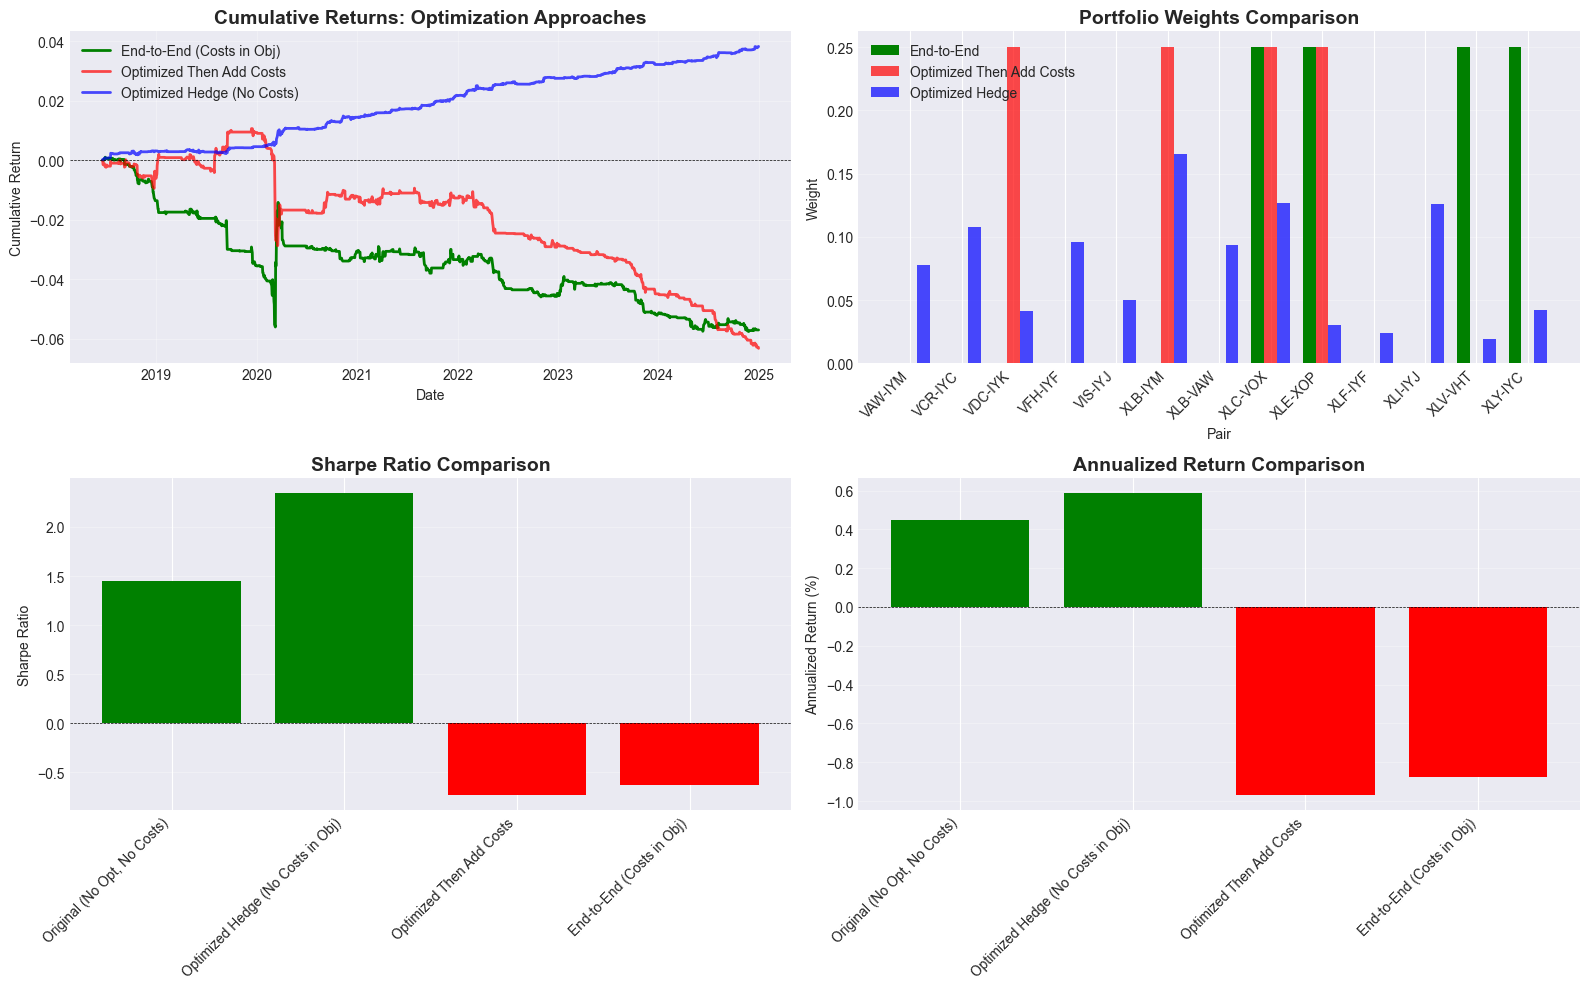


✓ End-to-end optimization complete!


In [53]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Cumulative Returns Comparison
axes[0, 0].plot(portfolio_returns_end_to_end.cumsum(), 
                label='End-to-End (Costs in Obj)', linewidth=2, color='green')
if 'portfolio_returns_with_costs' in locals():
    axes[0, 0].plot(portfolio_returns_with_costs.cumsum(), 
                    label='Optimized Then Add Costs', linewidth=2, alpha=0.7, color='red')
if 'portfolio_returns_optimized' in locals():
    axes[0, 0].plot(portfolio_returns_optimized.cumsum(), 
                    label='Optimized Hedge (No Costs)', linewidth=2, alpha=0.7, color='blue')
axes[0, 0].set_title('Cumulative Returns: Optimization Approaches', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# 2. Portfolio Weights Comparison
if 'optimal_weights_optimized' in locals() or 'optimal_weights_with_costs' in locals():
    pairs = sorted(set(list(optimal_weights_end_to_end.keys())))
    x = np.arange(len(pairs))
    width = 0.25
    
    end_to_end_vals = [optimal_weights_end_to_end.get(p, 0) for p in pairs]
    axes[0, 1].bar(x - width, end_to_end_vals, width, label='End-to-End', color='green')
    
    if 'optimal_weights_with_costs' in locals():
        with_costs_vals = [optimal_weights_with_costs.get(p, 0) for p in pairs]
        axes[0, 1].bar(x, with_costs_vals, width, label='Optimized Then Add Costs', color='red', alpha=0.7)
    
    if 'optimal_weights_optimized' in locals():
        opt_vals = [optimal_weights_optimized.get(p, 0) for p in pairs]
        axes[0, 1].bar(x + width, opt_vals, width, label='Optimized Hedge', color='blue', alpha=0.7)
    
    axes[0, 1].set_title('Portfolio Weights Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Pair')
    axes[0, 1].set_ylabel('Weight')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(pairs, rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 3. Sharpe Ratio Comparison
if len(comparison_df) > 0:
    axes[1, 0].bar(range(len(comparison_df)), comparison_df['Sharpe Ratio'], 
                   color=['red' if x < 0 else 'green' for x in comparison_df['Sharpe Ratio']])
    axes[1, 0].set_xticks(range(len(comparison_df)))
    axes[1, 0].set_xticklabels(comparison_df['Approach'], rotation=45, ha='right')
    axes[1, 0].set_title('Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Sharpe Ratio')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# 4. Annualized Return Comparison
if len(comparison_df) > 0:
    axes[1, 1].bar(range(len(comparison_df)), comparison_df['Annualized Return'] * 100,
                   color=['red' if x < 0 else 'green' for x in comparison_df['Annualized Return']])
    axes[1, 1].set_xticks(range(len(comparison_df)))
    axes[1, 1].set_xticklabels(comparison_df['Approach'], rotation=45, ha='right')
    axes[1, 1].set_title('Annualized Return Comparison', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Annualized Return (%)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ End-to-end optimization complete!")
